In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import os

path = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/")

START_DATE_STR = "05-01-2026"
END_DATE_STR   = "09-01-2026"
DATE_FORMAT = "%d-%m-%Y"

start_date = pd.to_datetime(START_DATE_STR, format=DATE_FORMAT)
end_date   = pd.to_datetime(END_DATE_STR, format=DATE_FORMAT)

# --------------------------------------------------
# Date extractor (DD-MM-YYYY anywhere in filename)
# --------------------------------------------------
def extract_date_from_filename(fname):
    m = re.search(r"\d{2}-\d{2}-\d{4}", fname)
    if not m:
        return None
    return pd.to_datetime(m.group(), format="%d-%m-%Y")

# --------------------------------------------------
# Select only 19–23 Jan 2026 files
# --------------------------------------------------
files = []
for f in path.glob("*.csv"):
    d = extract_date_from_filename(f.name)
    if d is not None and start_date <= d <= end_date:
        files.append((f, d))

files = sorted(files, key=lambda x: x[1])

print("Files to read:")
for f, d in files:
    print(f.name, "->", d.date())

# --------------------------------------------------
# Read + concat
# --------------------------------------------------
dfs = []
for f, d in files:
    df = pd.read_csv(f)
    df["date"] = d
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# --------------------------------------------------
# Reorder columns: date | range_m | time...
# --------------------------------------------------
df.insert(0, "date", df.pop("date"))
df.insert(1, "range_m", df.pop("range_m"))

print("Final shape:", df.shape)
print("Dates loaded:", df["date"].unique())

Files to read:
05-01-2026.csv -> 2026-01-05
06-01-2026.csv -> 2026-01-06
07-01-2026.csv -> 2026-01-07
08-01-2026.csv -> 2026-01-08
09-01-2026.csv -> 2026-01-09
Final shape: (10000, 50)
Dates loaded: <DatetimeArray>
['2026-01-05 00:00:00', '2026-01-06 00:00:00', '2026-01-07 00:00:00',
 '2026-01-08 00:00:00', '2026-01-09 00:00:00']
Length: 5, dtype: datetime64[ns]


In [3]:
df

,date,range_m,00.05,00.35,01.05,01.35,02.05,02.35,03.05,03.35,...,19.05,19.35,20.05,20.35,21.05,21.35,22.05,22.35,23.05,23.35
0,2026-01-05,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
1,2026-01-05,3.75,0.000031,0.000039,0.000062,0.000144,0.000055,0.000099,0.000051,0.000073,...,0.000105,0.000066,NaN,0.000039,0.000043,0.000086,0.000077,0.000051,NaN,0.000080
2,2026-01-05,7.50,0.000233,0.000202,0.000410,0.001663,0.000339,0.000911,0.000278,0.000524,...,0.001151,0.000526,NaN,0.000235,0.000258,0.000831,0.000671,0.000324,NaN,0.000697
3,2026-01-05,11.25,0.000757,0.000552,0.001299,0.005569,0.001060,0.002954,0.000768,0.001639,...,0.004915,0.002064,NaN,0.000673,0.000785,0.003304,0.002532,0.000954,NaN,0.002558
4,2026-01-05,15.00,0.001346,0.000982,0.002311,0.009892,0.001886,0.005248,0.001364,0.002912,...,0.008792,0.003696,NaN,0.001196,0.001396,0.005902,0.004515,0.001695,NaN,0.004557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2026-01-09,7481.25,-0.378035,-0.521201,-0.382927,-0.403797,-0.381389,-0.391928,-0.417974,-0.426583,...,-0.407257,-0.563690,-0.343553,-0.344943,-0.381868,-0.386444,-0.384327,-0.377408,-0.553047,-0.385477
9996,2026-01-09,7485.00,-0.378414,-0.521723,-0.383311,-0.404202,-0.381771,-0.392321,-0.418394,-0.427011,...,-0.407665,-0.564256,-0.343897,-0.345289,-0.382251,-0.386831,-0.384712,-0.377786,-0.553602,-0.385864
9997,2026-01-09,7488.75,-0.378794,-0.522246,-0.383695,-0.404607,-0.382154,-0.392714,-0.418813,-0.427439,...,-0.408074,-0.564821,-0.344242,-0.345635,-0.382634,-0.387219,-0.385098,-0.378165,-0.554156,-0.386250
9998,2026-01-09,7492.50,-0.379173,-0.522769,-0.384079,-0.405013,-0.382537,-0.393107,-0.419232,-0.427867,...,-0.408483,-0.565387,-0.344587,-0.345982,-0.383017,-0.387607,-0.385484,-0.378544,-0.554712,-0.386637


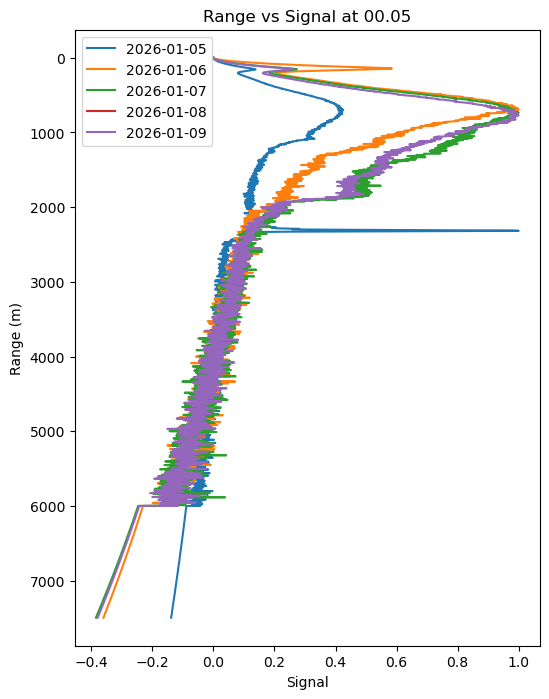


--- 00.05 ---
dtype: float64
NaNs: 2000
min/max: -0.3851687754514569 1.0


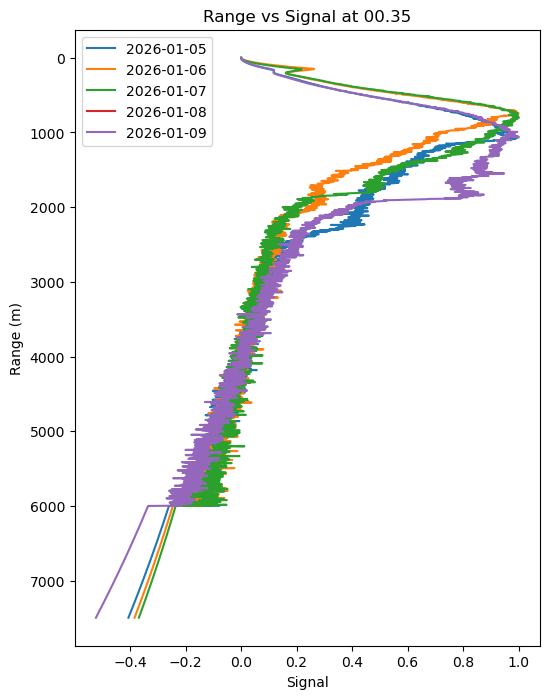


--- 00.35 ---
dtype: float64
NaNs: 2000
min/max: -0.5232927466821203 1.0


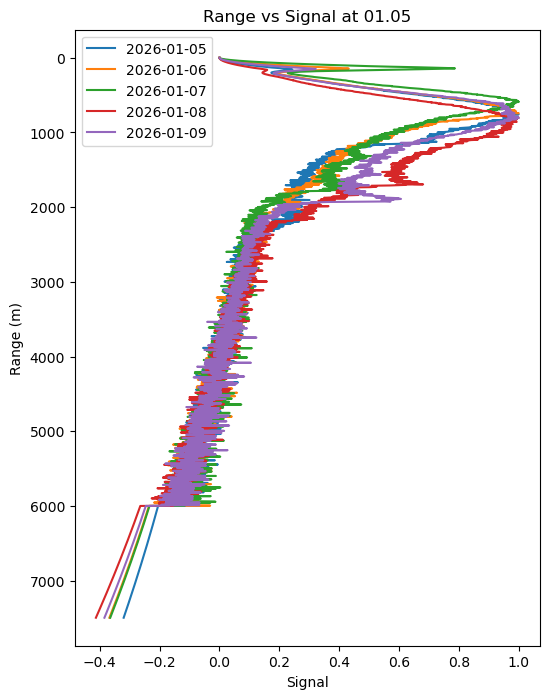


--- 01.05 ---
dtype: float64
NaNs: 0
min/max: -0.4129026518074425 1.0


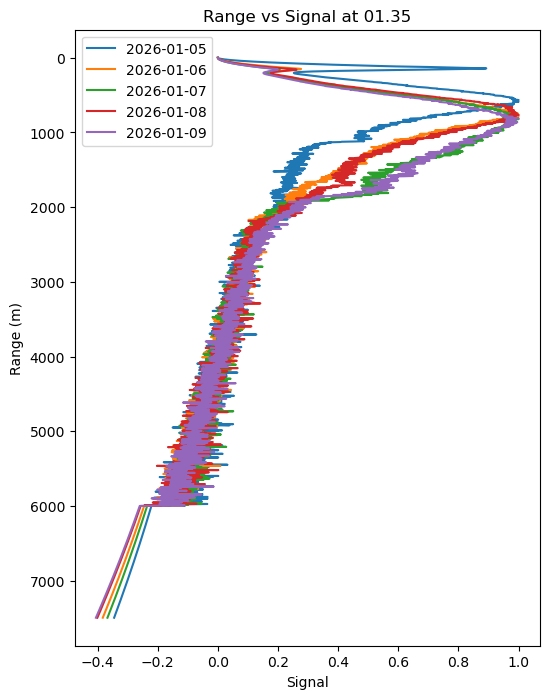


--- 01.35 ---
dtype: float64
NaNs: 0
min/max: -0.4054181040392657 1.0


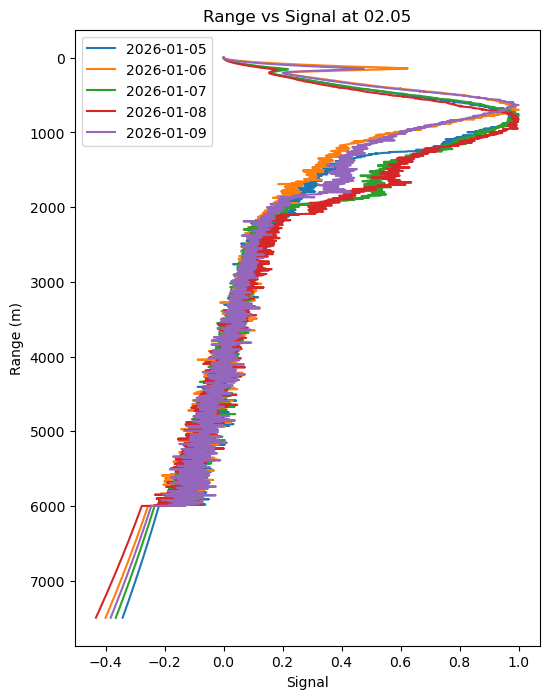


--- 02.05 ---
dtype: float64
NaNs: 0
min/max: -0.4328893125255832 1.0


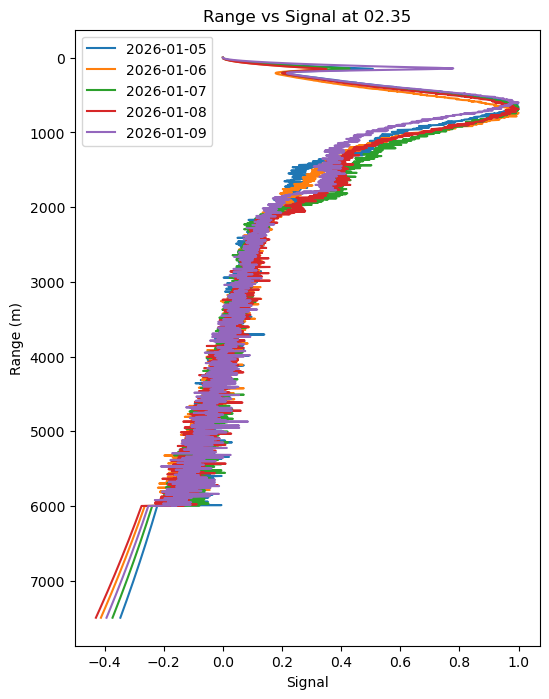


--- 02.35 ---
dtype: float64
NaNs: 0
min/max: -0.4293310454030032 1.0


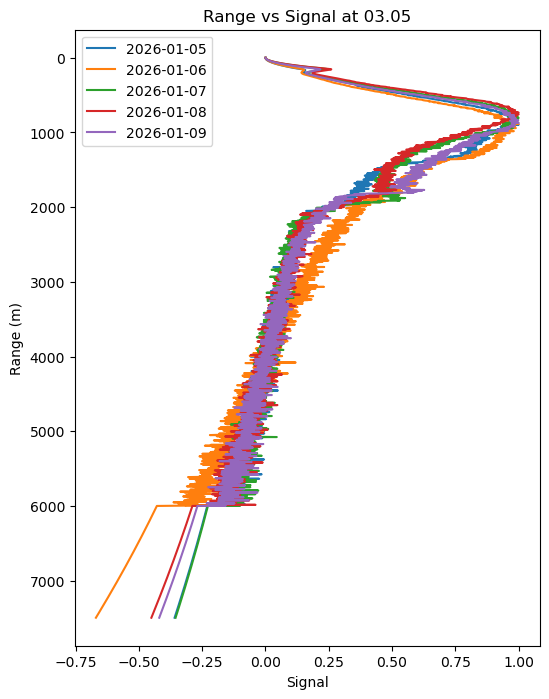


--- 03.05 ---
dtype: float64
NaNs: 0
min/max: -0.6698311256007071 1.0


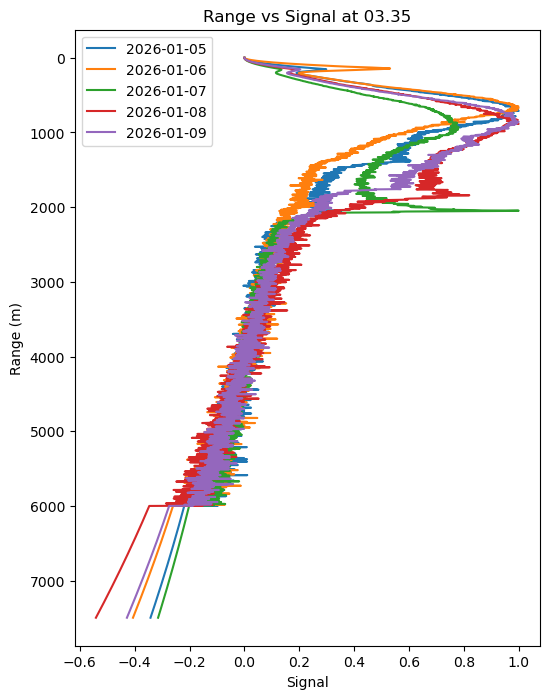


--- 03.35 ---
dtype: float64
NaNs: 0
min/max: -0.5413526979248852 1.0


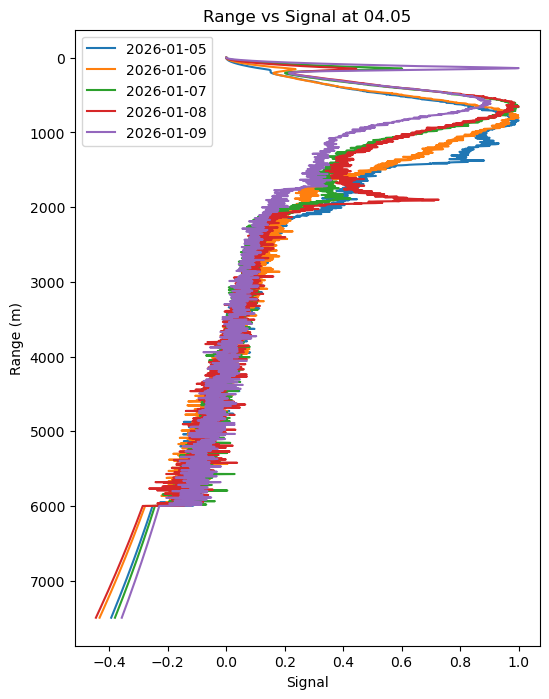


--- 04.05 ---
dtype: float64
NaNs: 0
min/max: -0.4456688222069573 1.0


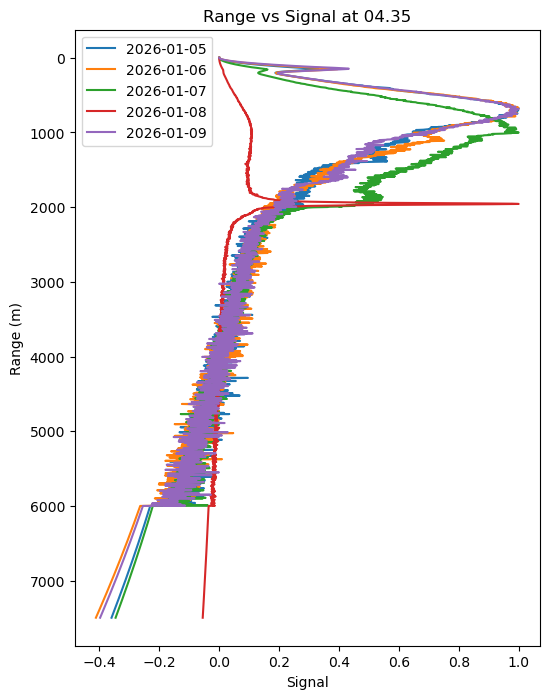


--- 04.35 ---
dtype: float64
NaNs: 0
min/max: -0.4117213982150441 1.0


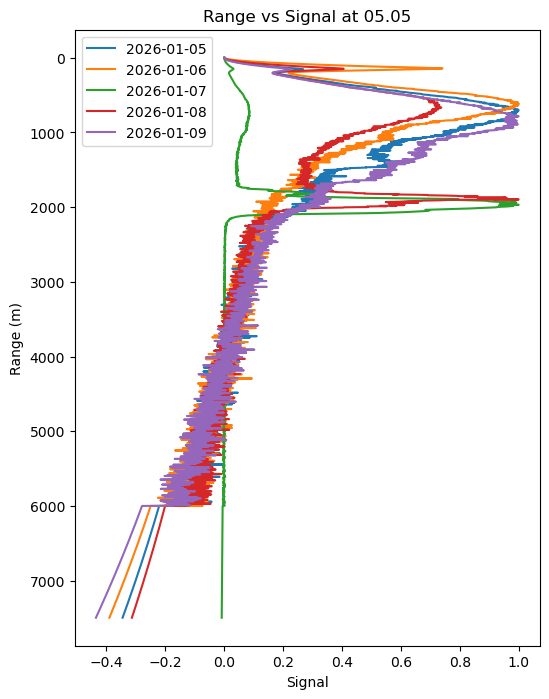


--- 05.05 ---
dtype: float64
NaNs: 0
min/max: -0.4359492215966446 1.0


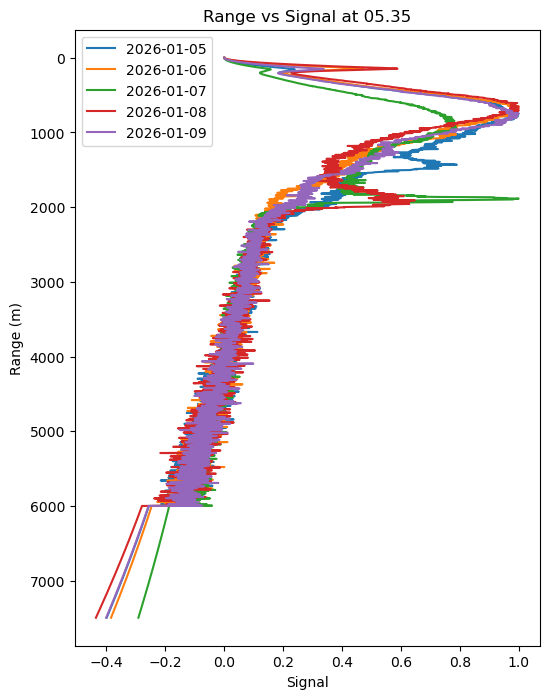


--- 05.35 ---
dtype: float64
NaNs: 0
min/max: -0.4357205995879404 1.0


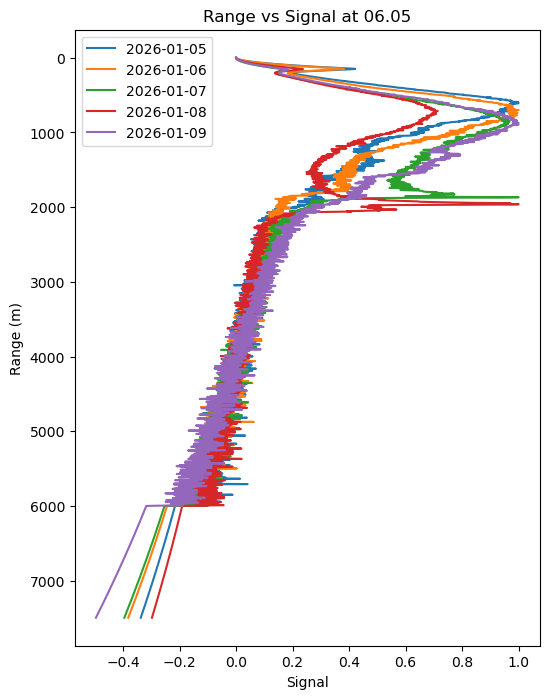


--- 06.05 ---
dtype: float64
NaNs: 0
min/max: -0.4959598454149609 1.0


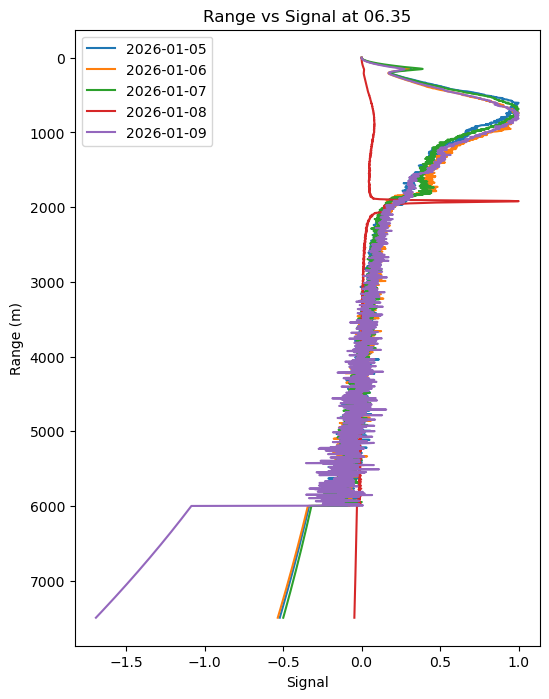


--- 06.35 ---
dtype: float64
NaNs: 0
min/max: -1.691396247380884 1.0


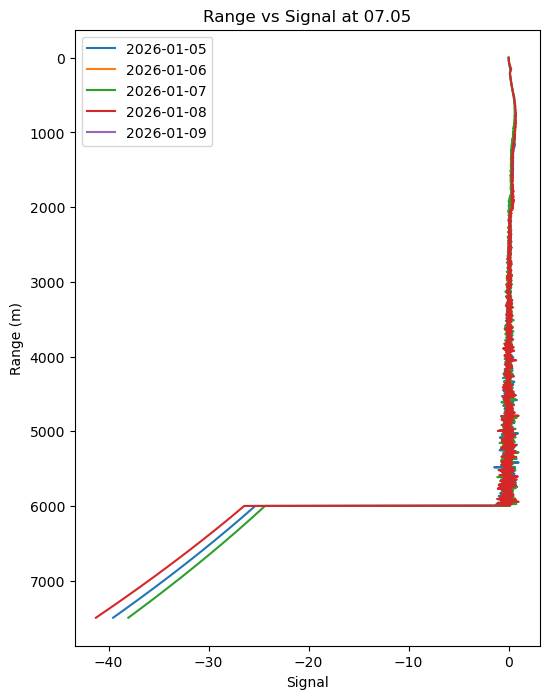


--- 07.05 ---
dtype: float64
NaNs: 4000
min/max: -41.27628934735693 1.0


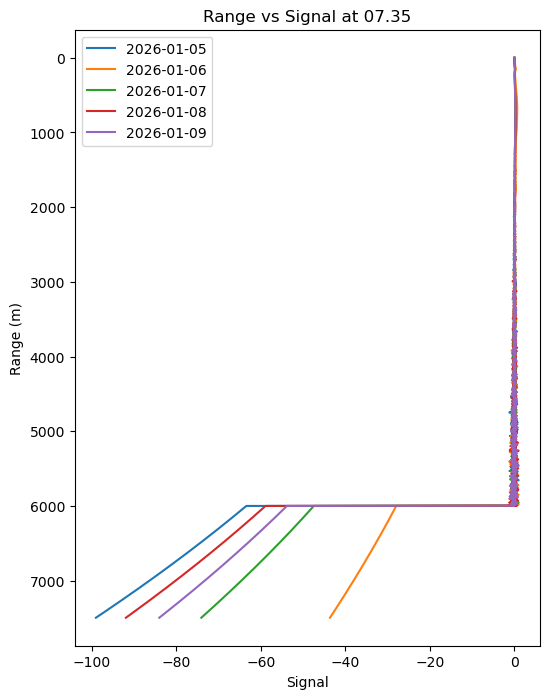


--- 07.35 ---
dtype: float64
NaNs: 0
min/max: -98.9897819468257 1.0


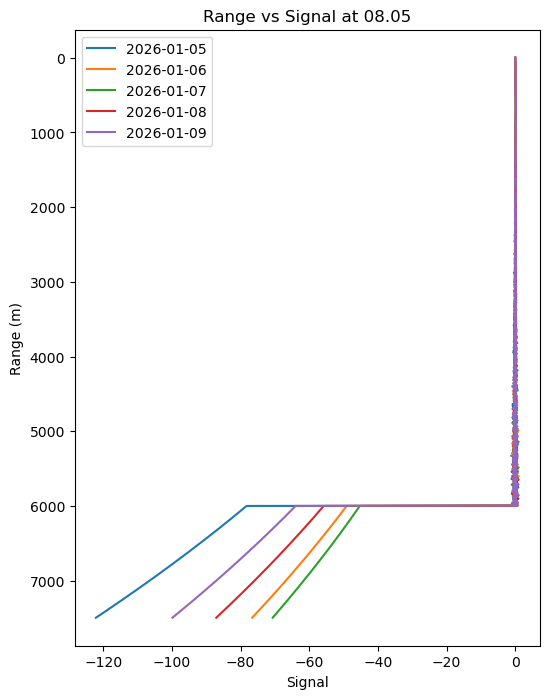


--- 08.05 ---
dtype: float64
NaNs: 0
min/max: -122.1343166158157 1.0


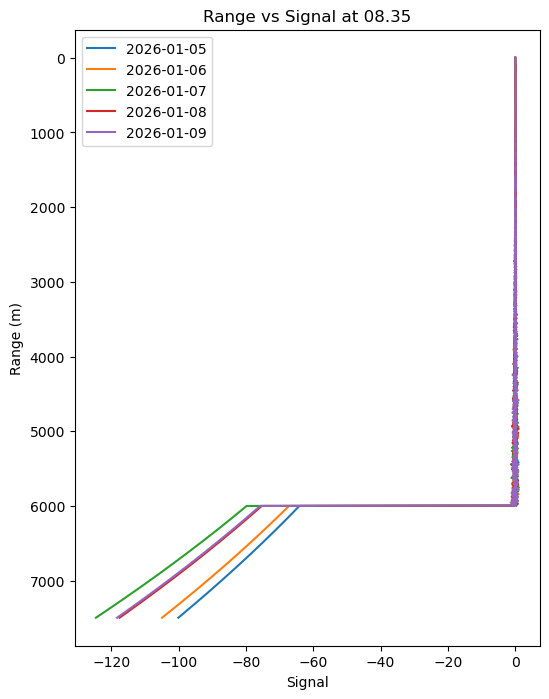


--- 08.35 ---
dtype: float64
NaNs: 0
min/max: -124.53462359734816 1.0


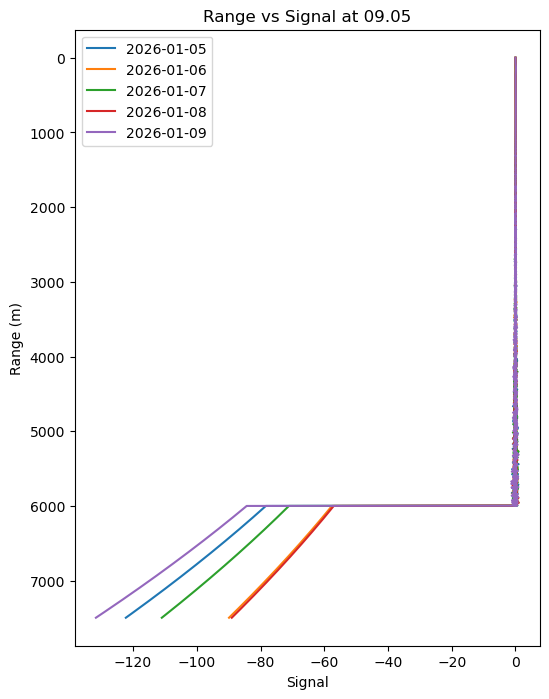


--- 09.05 ---
dtype: float64
NaNs: 0
min/max: -131.65960325423274 1.0


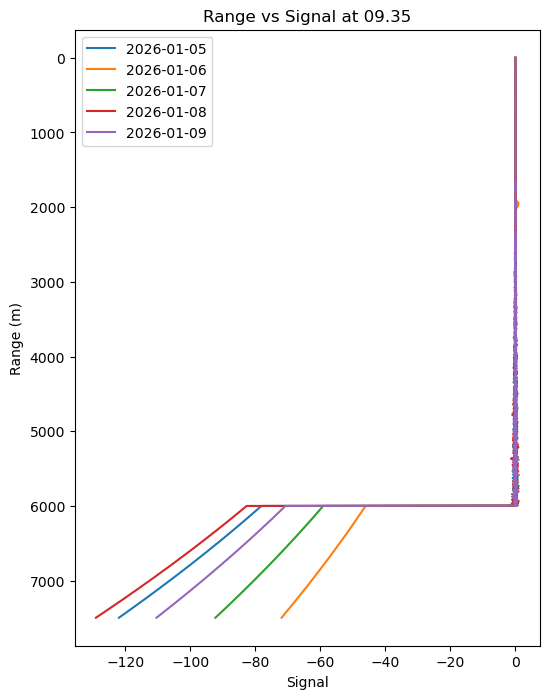


--- 09.35 ---
dtype: float64
NaNs: 0
min/max: -129.06557968273222 1.0


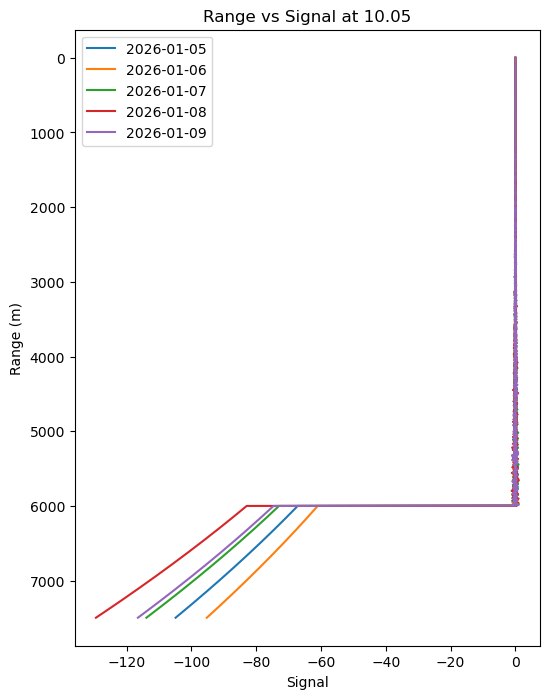


--- 10.05 ---
dtype: float64
NaNs: 0
min/max: -129.45644721603284 1.0


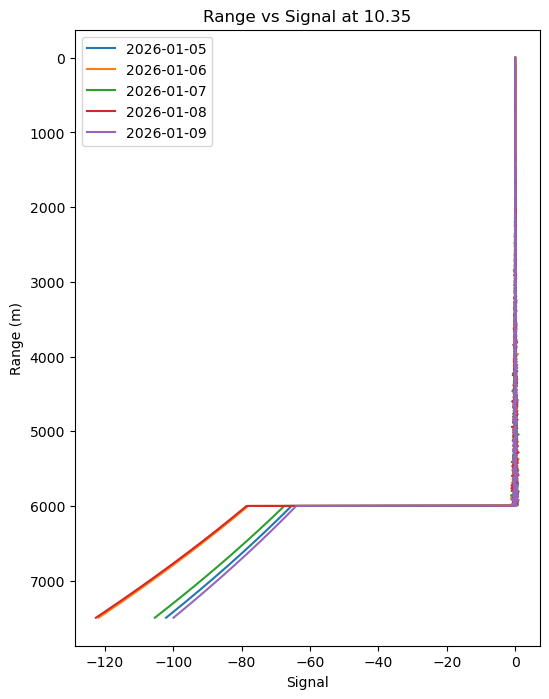


--- 10.35 ---
dtype: float64
NaNs: 0
min/max: -122.6108085104113 1.0


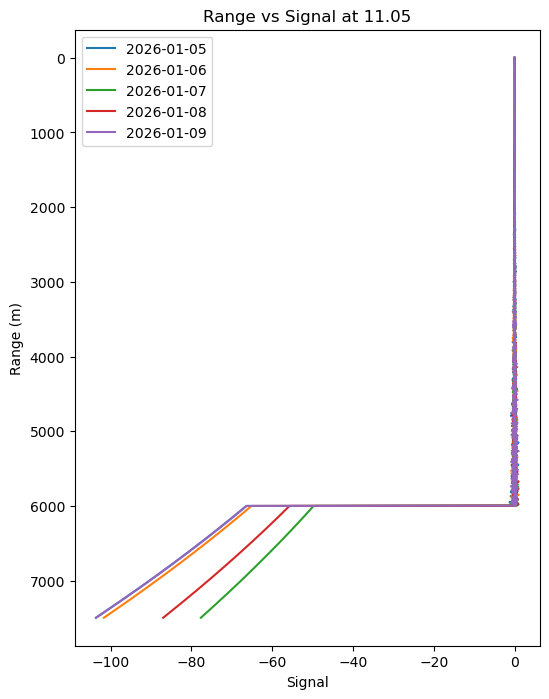


--- 11.05 ---
dtype: float64
NaNs: 0
min/max: -103.65889229419533 1.0


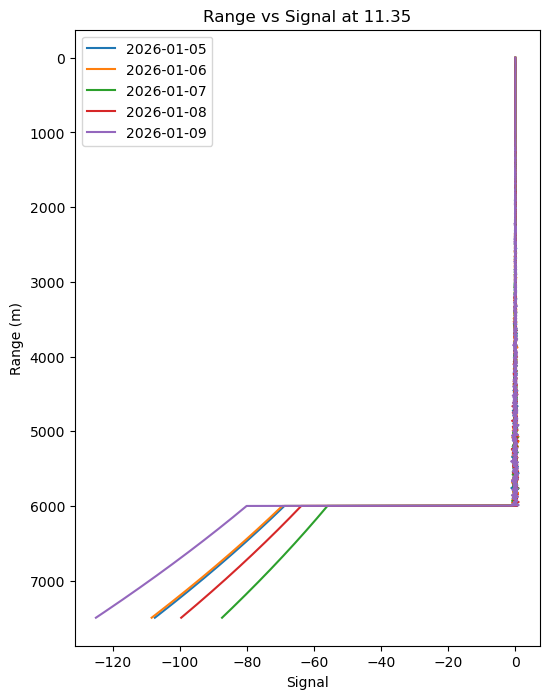


--- 11.35 ---
dtype: float64
NaNs: 0
min/max: -125.0440529619223 1.0


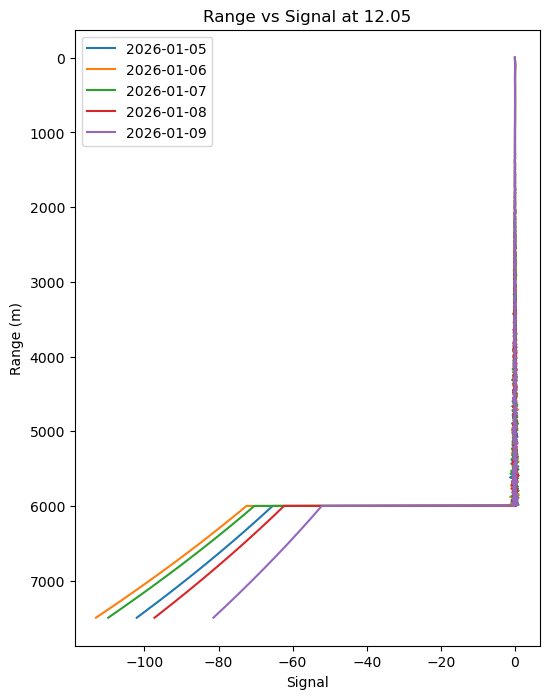


--- 12.05 ---
dtype: float64
NaNs: 0
min/max: -113.08664590924649 1.0


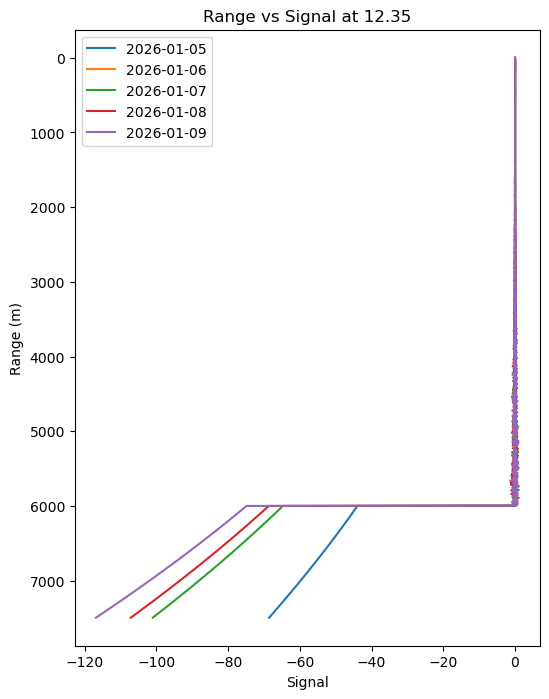


--- 12.35 ---
dtype: float64
NaNs: 2000
min/max: -116.86205081474168 1.0


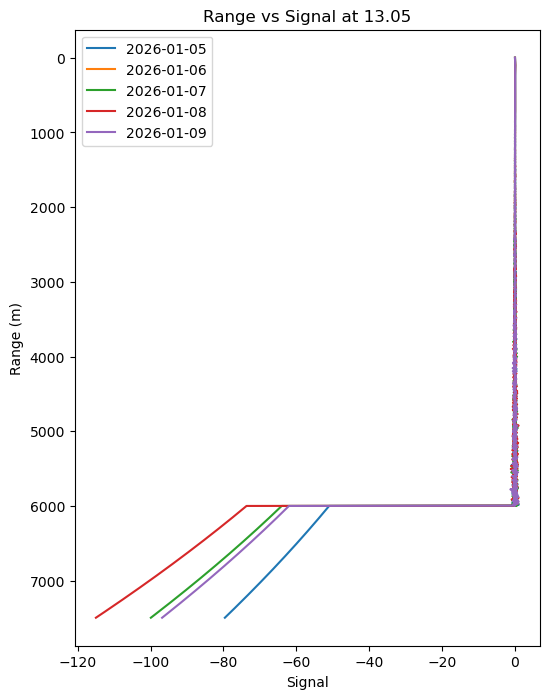


--- 13.05 ---
dtype: float64
NaNs: 2000
min/max: -114.9883794793462 1.0


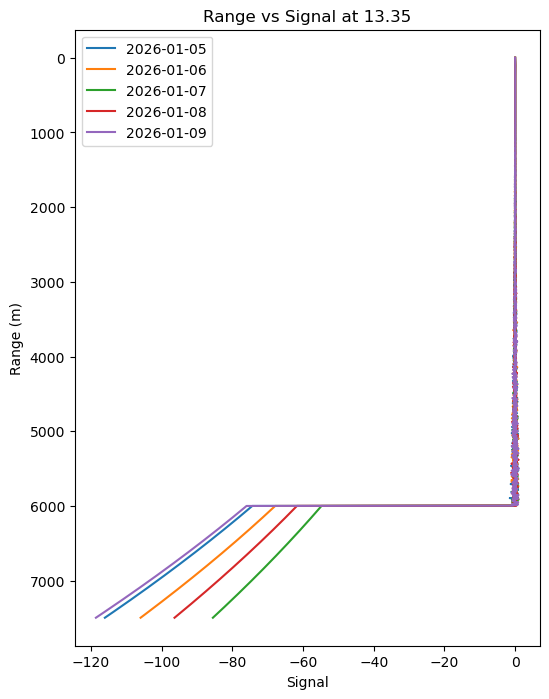


--- 13.35 ---
dtype: float64
NaNs: 0
min/max: -118.6354519875872 1.0


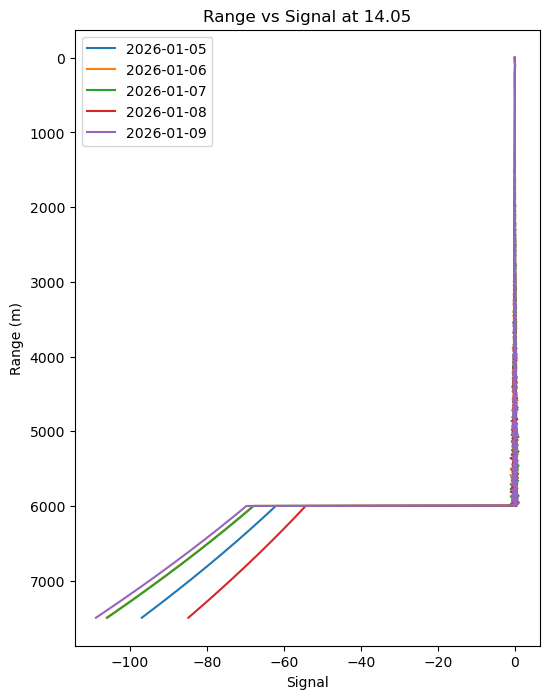


--- 14.05 ---
dtype: float64
NaNs: 0
min/max: -108.82180324575832 1.0


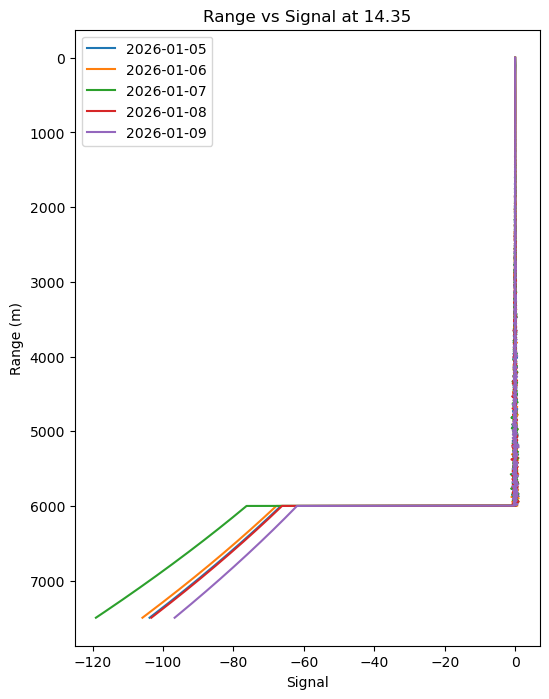


--- 14.35 ---
dtype: float64
NaNs: 0
min/max: -119.0411625112859 1.0


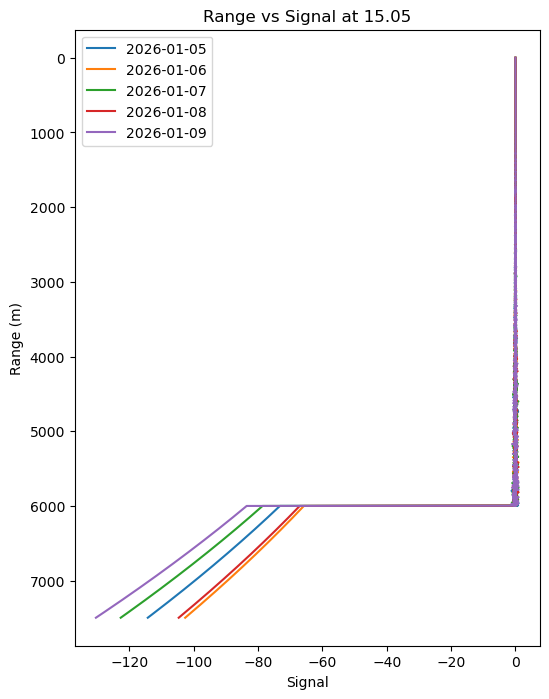


--- 15.05 ---
dtype: float64
NaNs: 0
min/max: -130.36068776583838 1.0


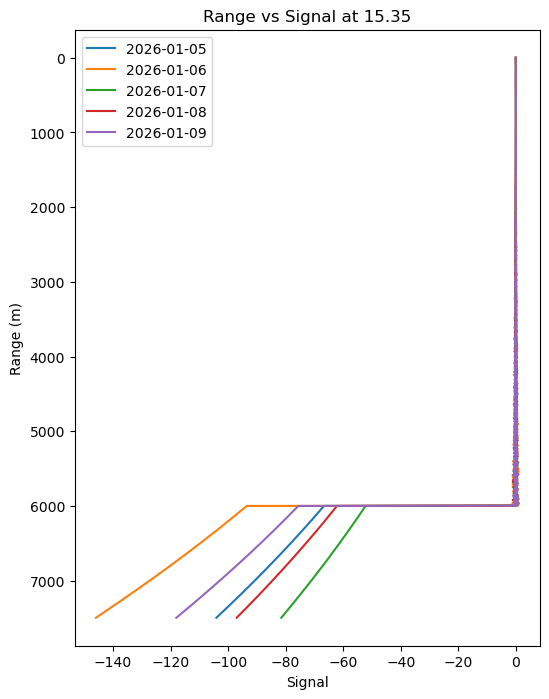


--- 15.35 ---
dtype: float64
NaNs: 0
min/max: -145.96500397015097 1.0


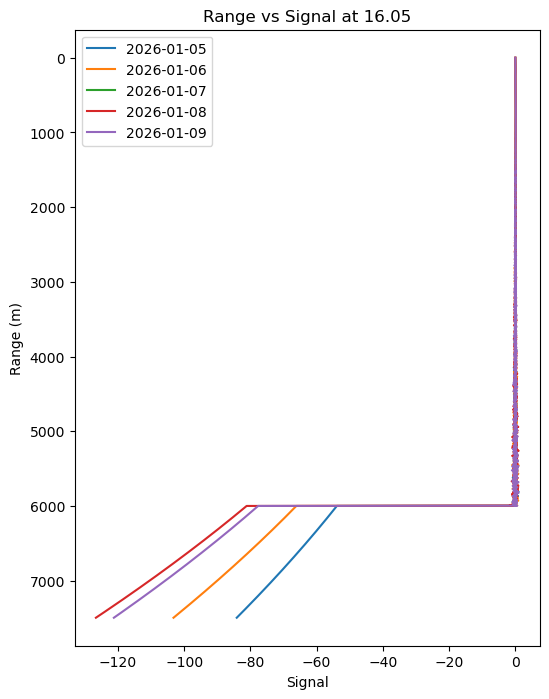


--- 16.05 ---
dtype: float64
NaNs: 2000
min/max: -126.6655622480707 1.0


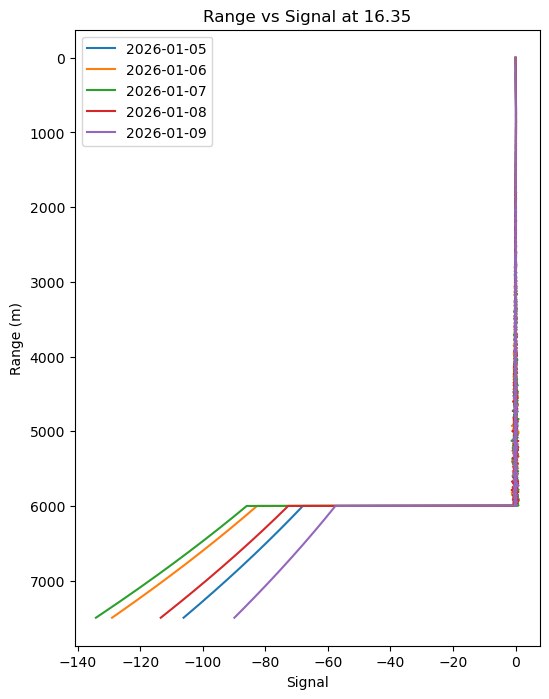


--- 16.35 ---
dtype: float64
NaNs: 0
min/max: -134.14021812152683 1.0


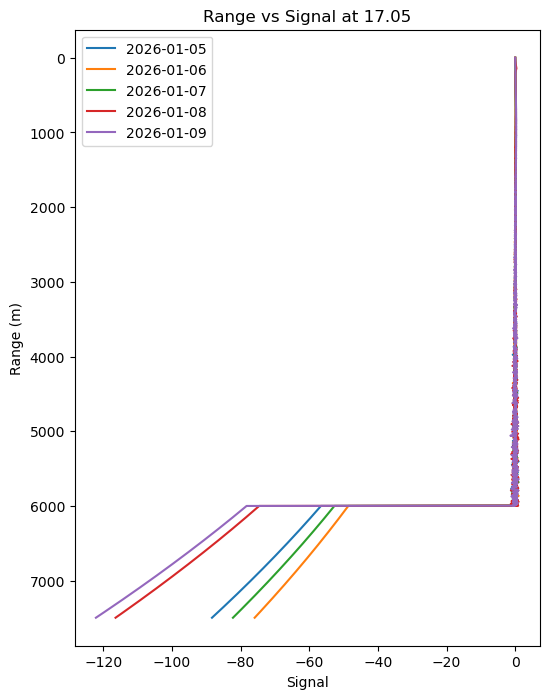


--- 17.05 ---
dtype: float64
NaNs: 0
min/max: -122.17106641029392 1.0


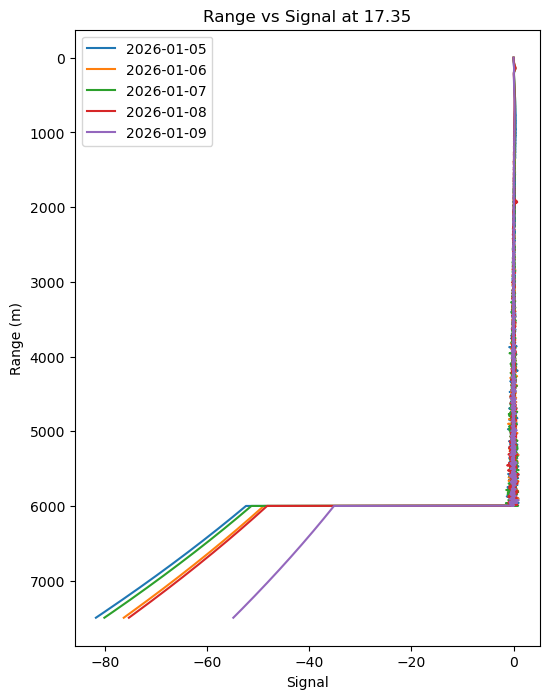


--- 17.35 ---
dtype: float64
NaNs: 0
min/max: -81.80610071742987 1.0


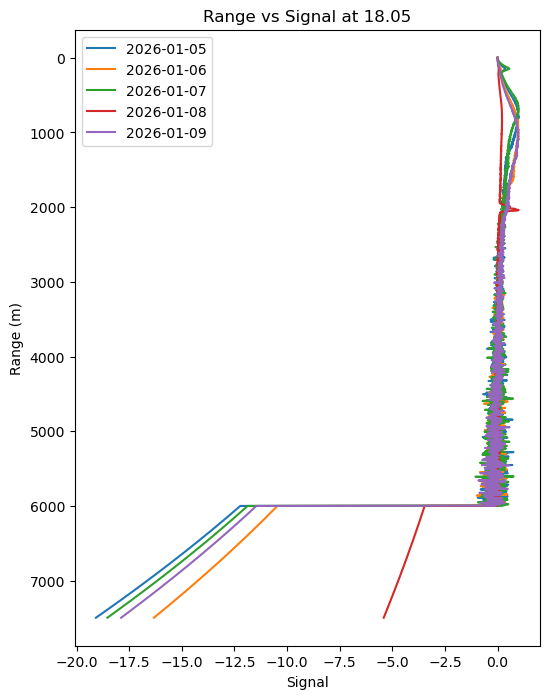


--- 18.05 ---
dtype: float64
NaNs: 0
min/max: -19.081360435950153 1.0


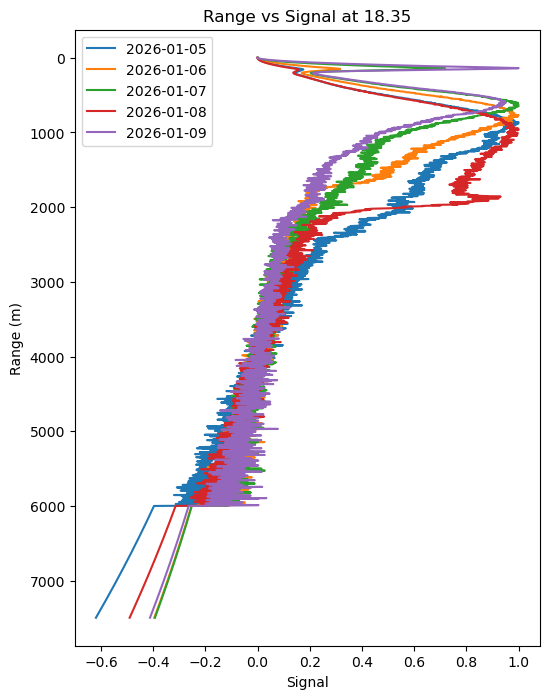


--- 18.35 ---
dtype: float64
NaNs: 0
min/max: -0.6190044736796035 1.0


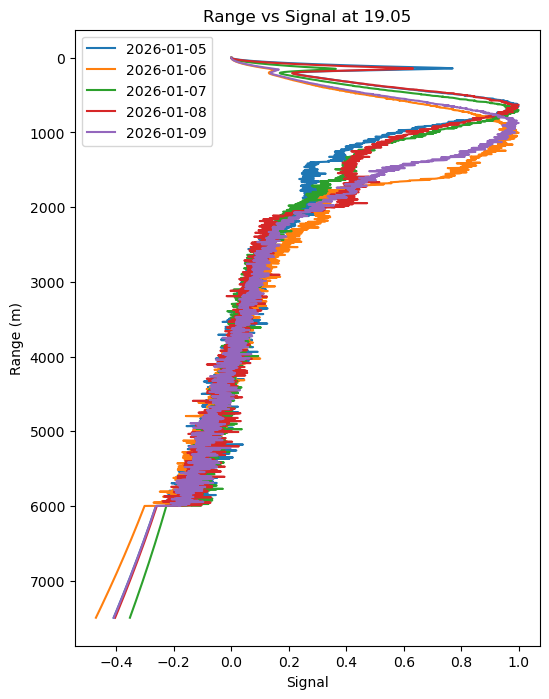


--- 19.05 ---
dtype: float64
NaNs: 0
min/max: -0.4712051259192625 1.0


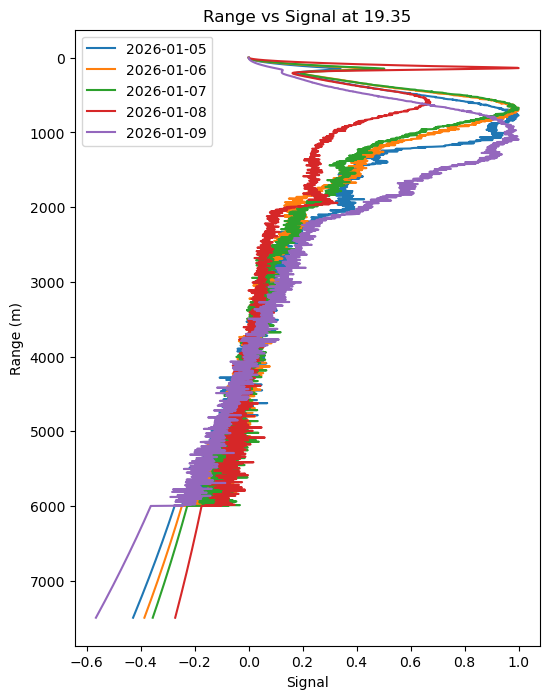


--- 19.35 ---
dtype: float64
NaNs: 0
min/max: -0.5659529376763209 1.0


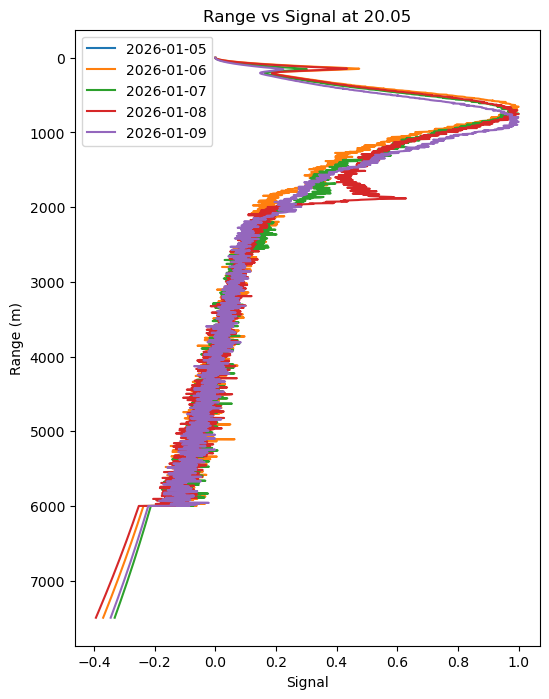


--- 20.05 ---
dtype: float64
NaNs: 2000
min/max: -0.3936211967871801 1.0


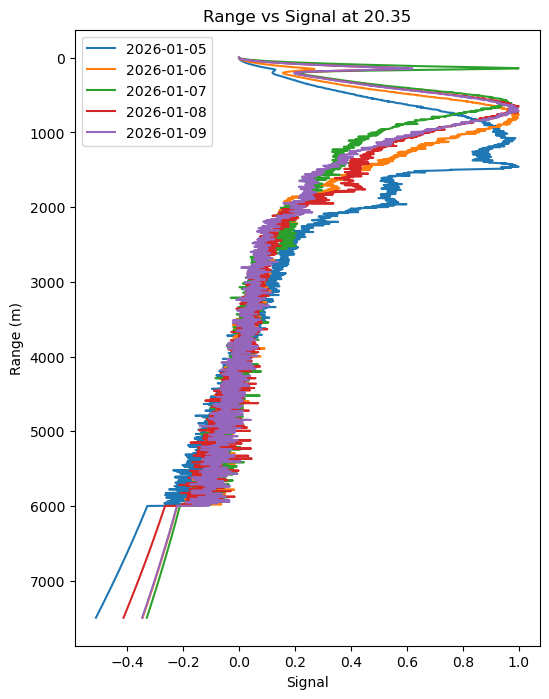


--- 20.35 ---
dtype: float64
NaNs: 0
min/max: -0.5116662114811334 1.0


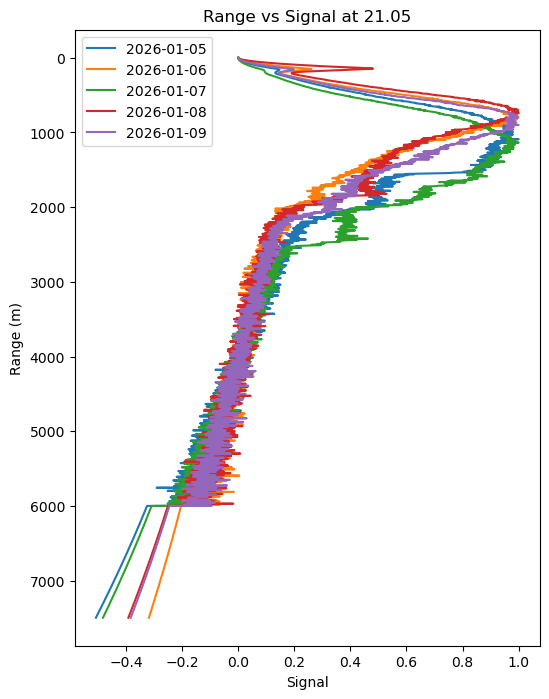


--- 21.05 ---
dtype: float64
NaNs: 0
min/max: -0.5075243597936515 1.0


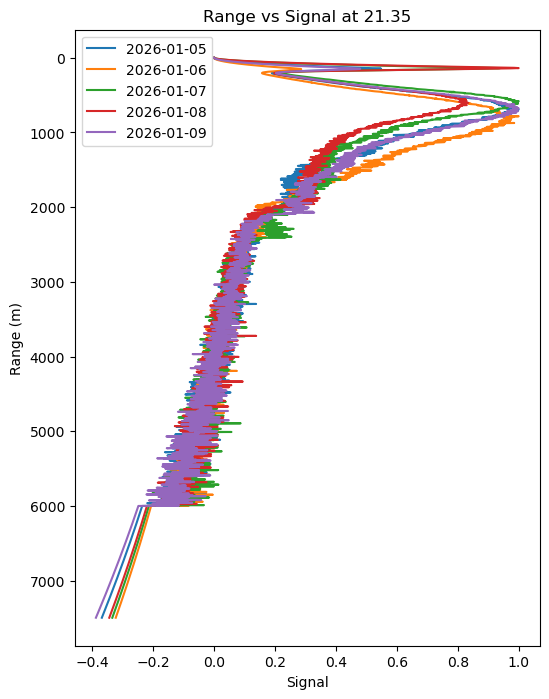


--- 21.35 ---
dtype: float64
NaNs: 0
min/max: -0.387995006022213 1.0


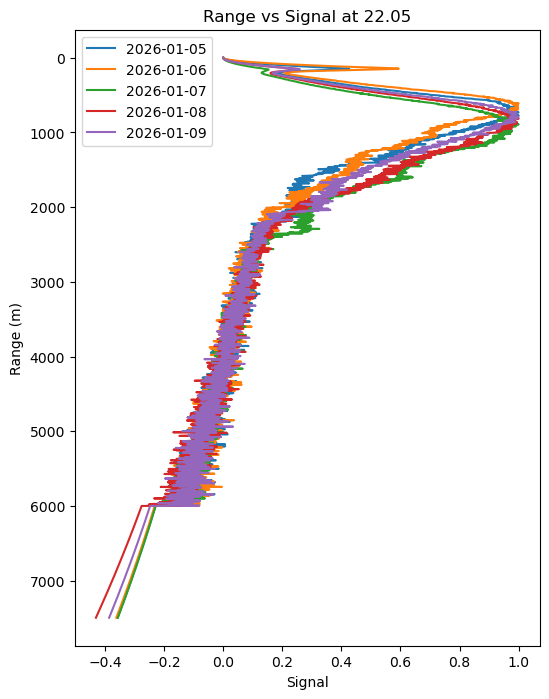


--- 22.05 ---
dtype: float64
NaNs: 0
min/max: -0.4306151236552419 1.0


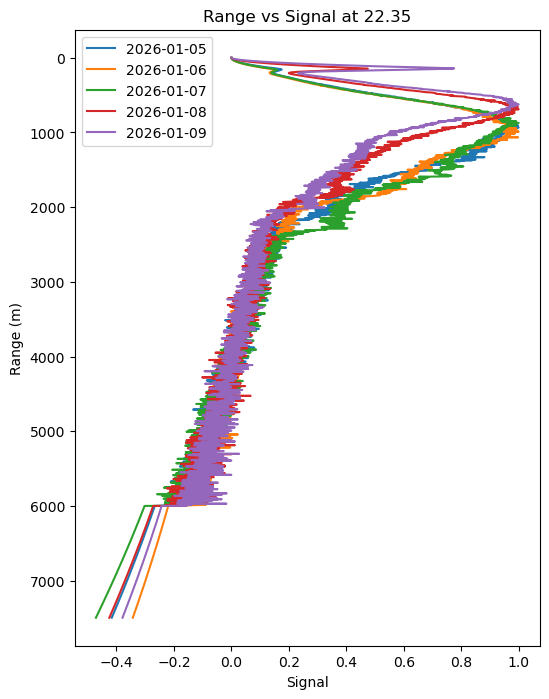


--- 22.35 ---
dtype: float64
NaNs: 0
min/max: -0.4714777335863689 1.0


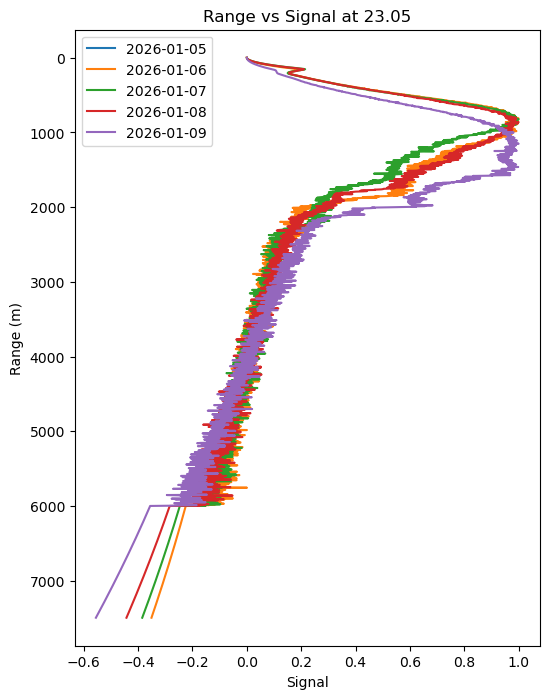


--- 23.05 ---
dtype: float64
NaNs: 2000
min/max: -0.5552669338868579 1.0


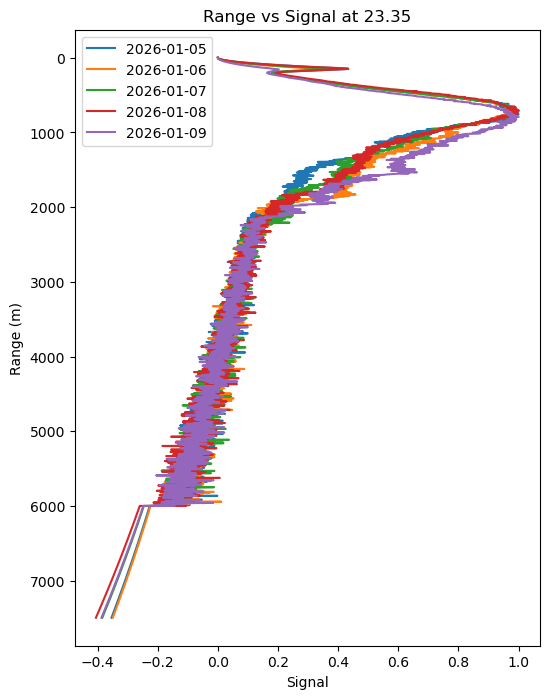


--- 23.35 ---
dtype: float64
NaNs: 0
min/max: -0.4053787552411375 1.0


In [5]:
# --- make sure date is datetime ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range (inclusive) ---
mask = df["date"].between(start_date, end_date, inclusive="both")

df_sel = df.loc[mask].copy()

# --- find time columns (everything except date, range_m) ---
time_cols = [c for c in df_sel.columns if c not in ("date", "range_m")]

# --- make sure range is numeric ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

for t in time_cols:
    # ensure signal is numeric
    df_sel[t] = pd.to_numeric(df_sel[t], errors="coerce")

    fig, ax = plt.subplots(figsize=(6, 8), clear=True)

    for d, g in df_sel.groupby("date"):
        gg = g.dropna(subset=[t, "range_m"])
        ax.plot(
            gg[t].to_numpy(dtype=float),
            gg["range_m"].to_numpy(dtype=float),
            label=d.strftime("%Y-%m-%d"),
        )

    ax.invert_yaxis()
    ax.set_xlabel("Signal")          # "Range Square" sounded mismatched
    ax.set_ylabel("Range (m)")
    ax.set_title(f"Range vs Signal at {t}")
    ax.legend()
    plt.show()

    # --- correct debug for numeric data ---
    print("\n---", t, "---")
    print("dtype:", df_sel[t].dtype)
    print("NaNs:", int(df_sel[t].isna().sum()))
    print("min/max:", df_sel[t].min(), df_sel[t].max())


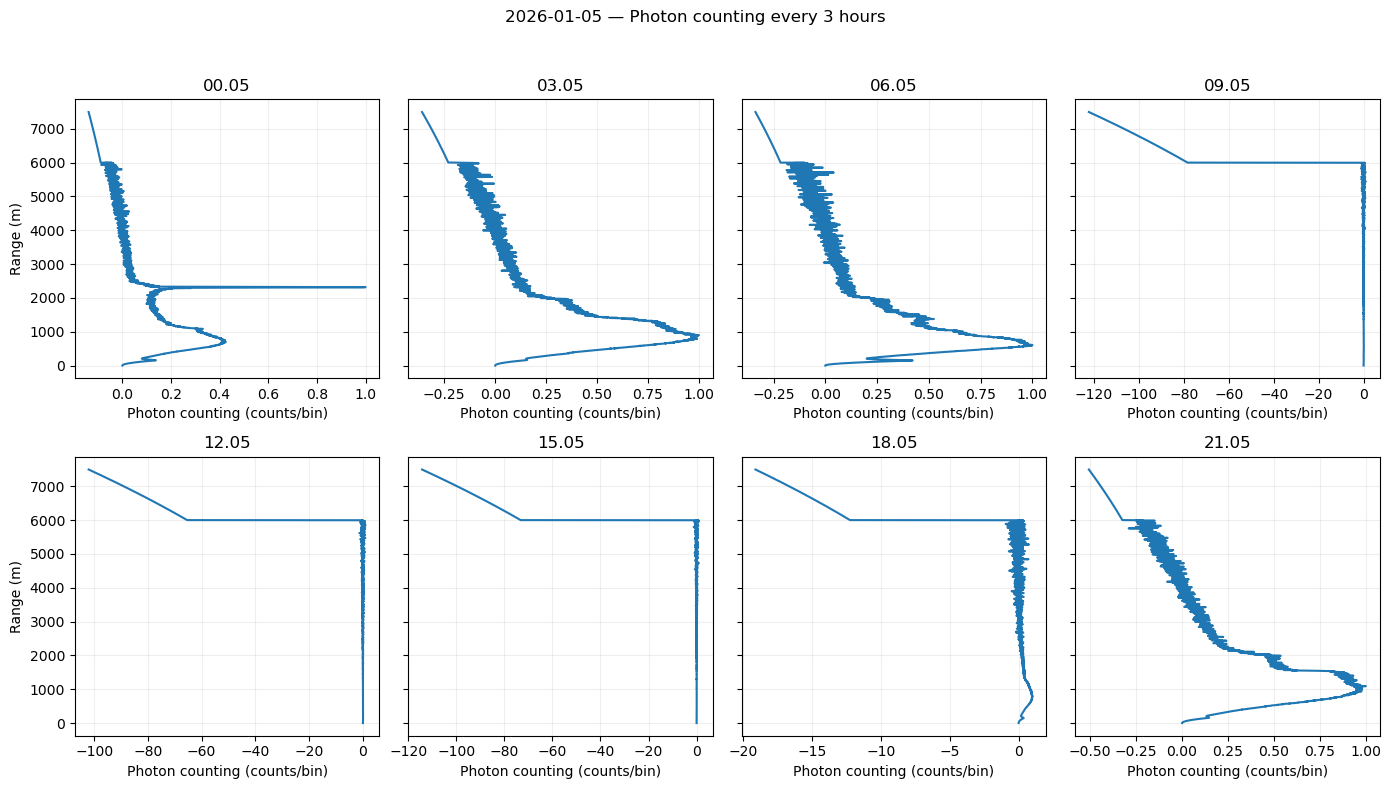

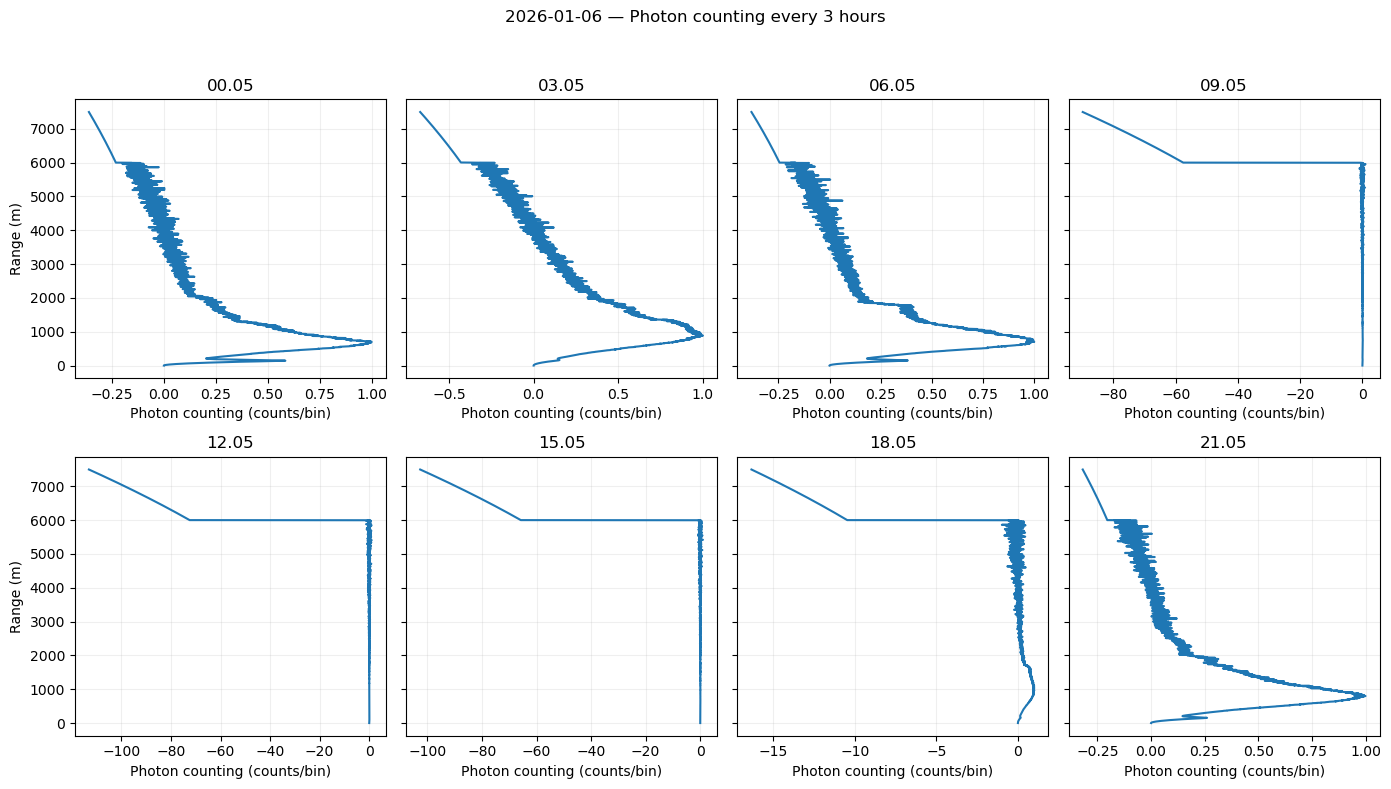

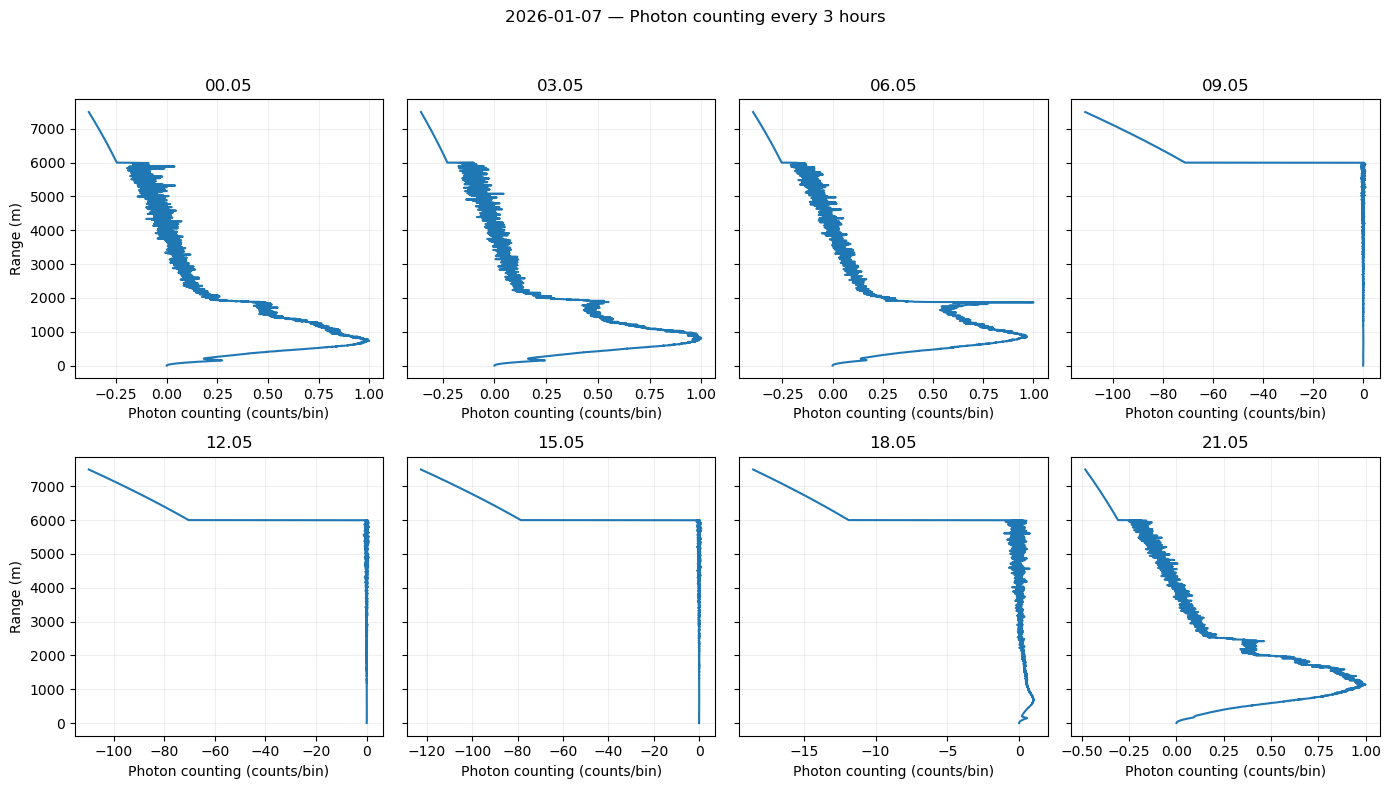

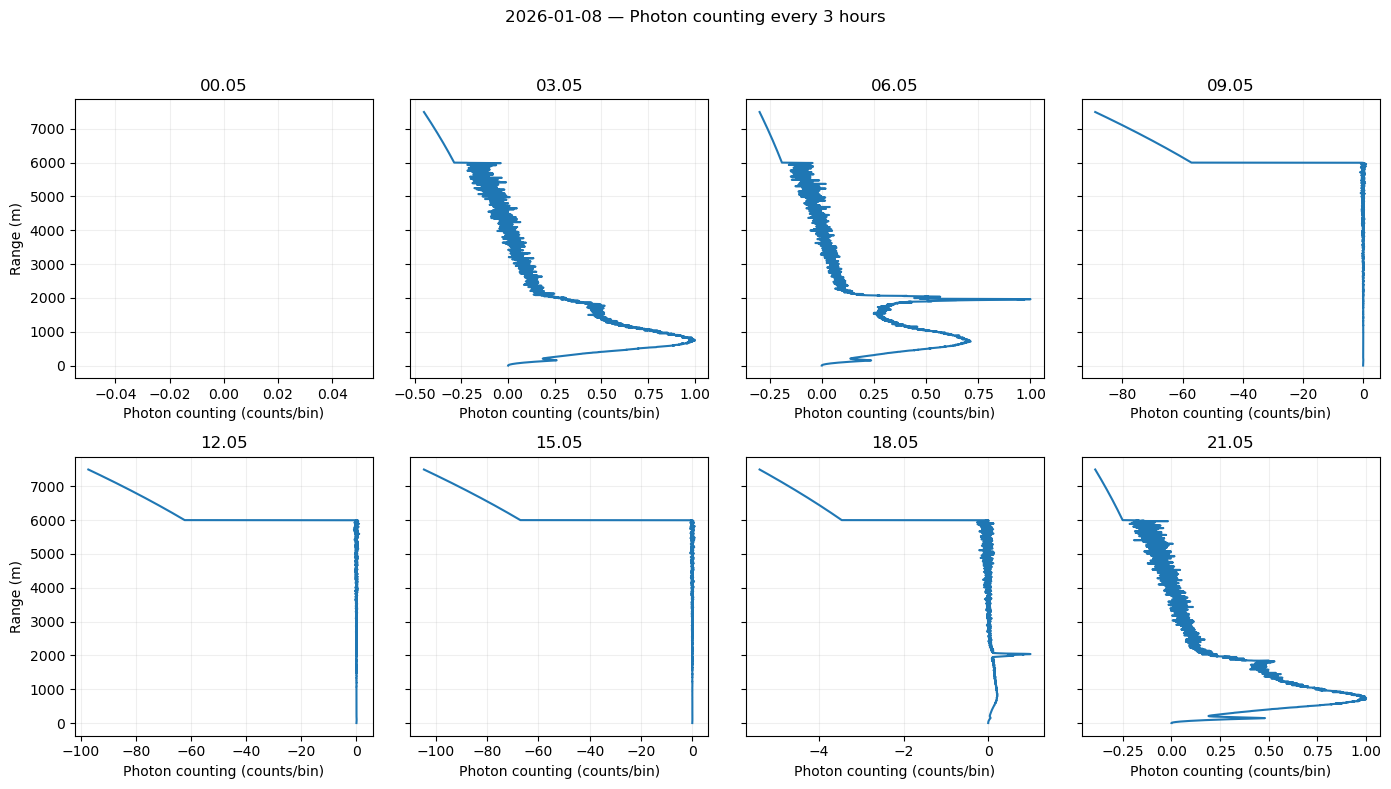

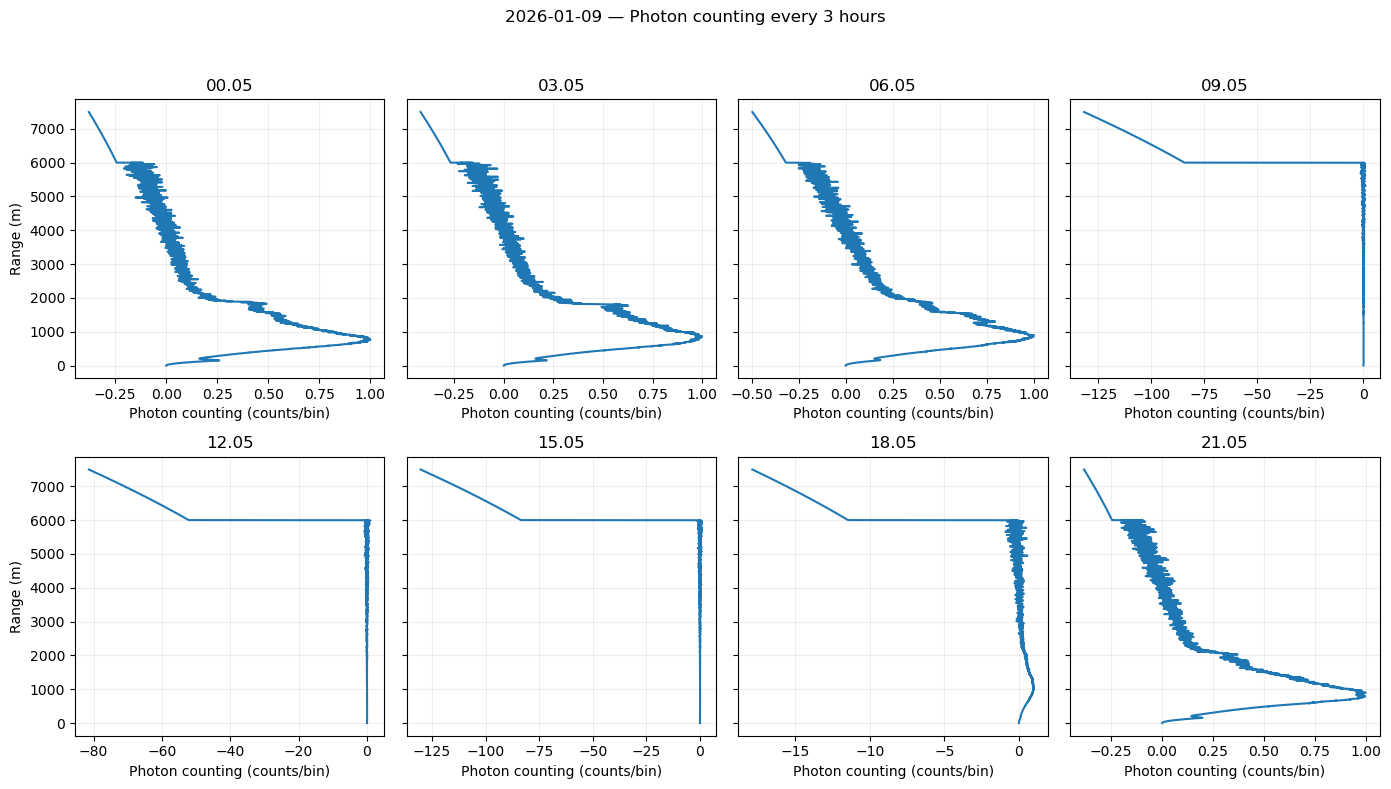

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --- make sure date is datetime ---
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range (inclusive) ---
mask = df["date"].between(start_date, end_date, inclusive="both")
df_sel = df.loc[mask].copy()

# --- make sure range is numeric ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

# --- time tags every 3 hours (choose .05 OR .35 depending on what your file has) ---
time_tags_3h = [f"{h:02d}.05" for h in range(0, 24, 3)]
# time_tags_3h = [f"{h:02d}.35" for h in range(0, 24, 3)]

# --- plot: one figure per day ---
for day, gday in df_sel.groupby(df_sel["date"].dt.date):

    fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharey=True, clear=True)
    axes = axes.ravel()

    for i, t in enumerate(time_tags_3h):
        ax = axes[i]

        if t not in gday.columns:
            ax.text(0.5, 0.5, f"Missing: {t}", ha="center", va="center")
            ax.set_title(t)
            ax.invert_yaxis()
            continue

        gg = gday.dropna(subset=["range_m", t]).copy()
        gg[t] = pd.to_numeric(gg[t], errors="coerce")
        gg = gg.dropna(subset=["range_m", t])

        ax.plot(gg[t].to_numpy(float), gg["range_m"].to_numpy(float))
        ax.set_title(t)
        ax.set_xlabel("Photon counting (counts/bin)")
        if i % 4 == 0:
            ax.set_ylabel("Range (m)")
        ax.invert_yaxis()
        ax.grid(True, alpha=0.2)

    fig.suptitle(f"{day} — Photon counting every 3 hours", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

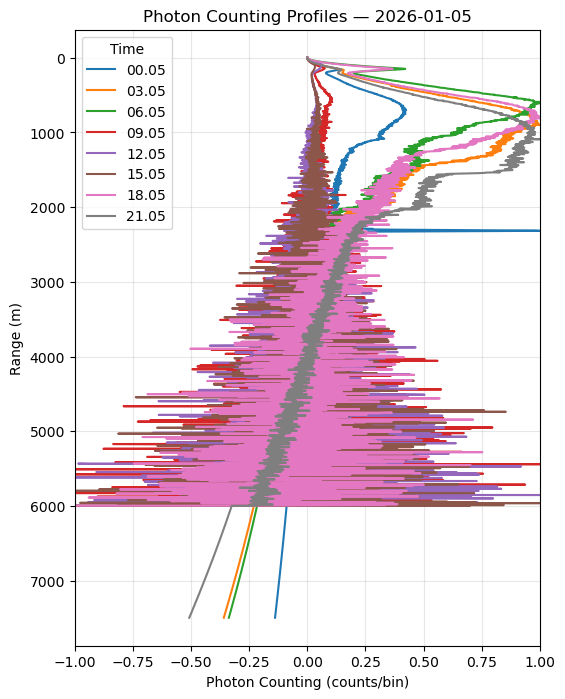

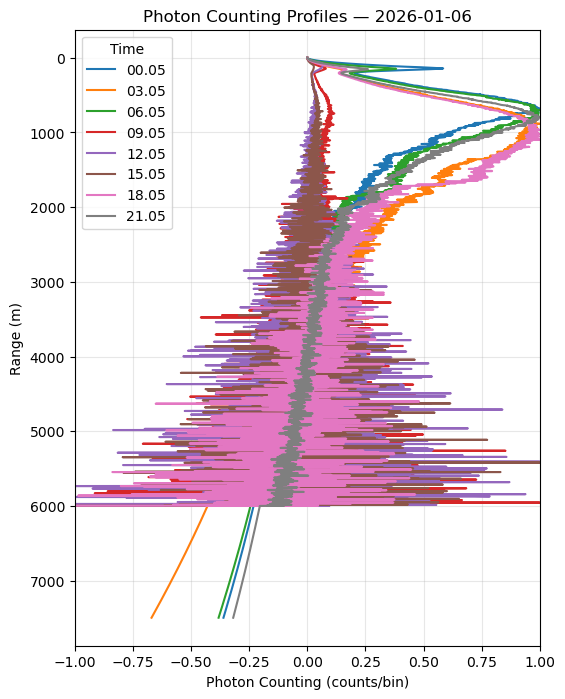

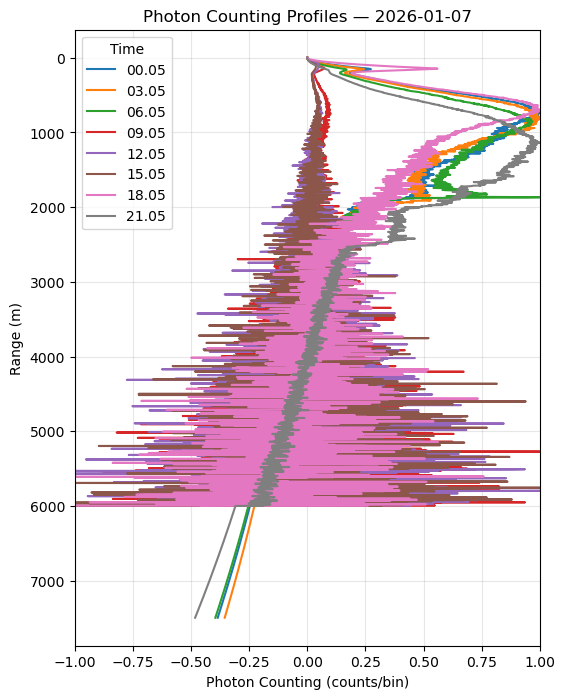

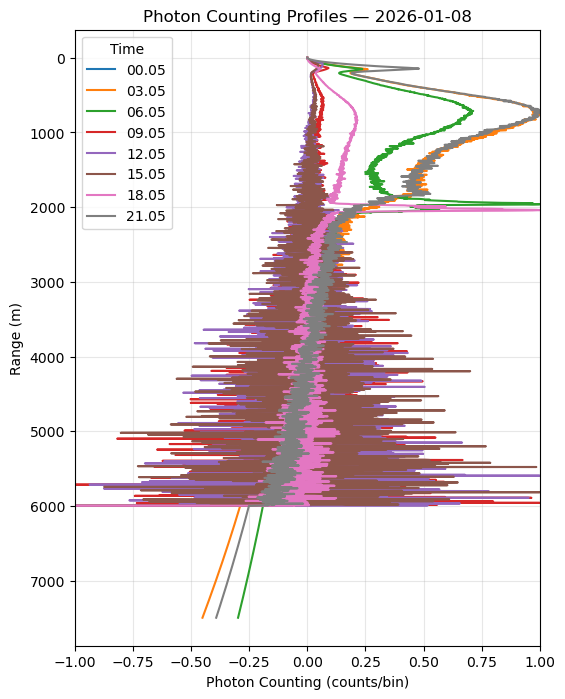

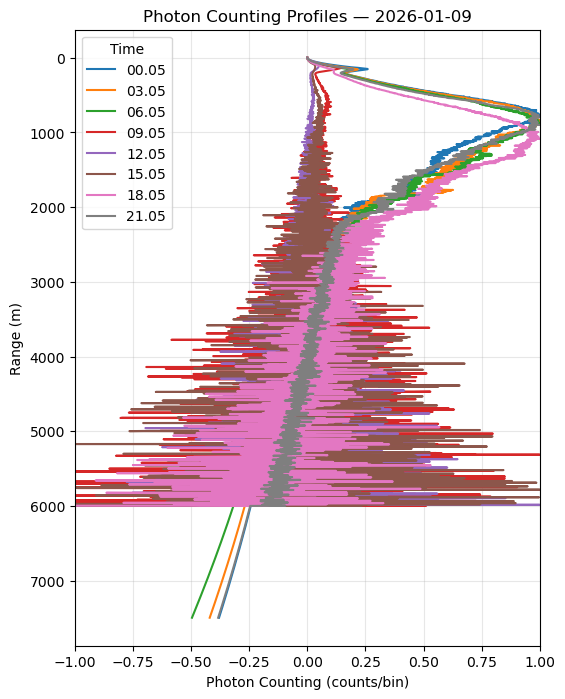

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --- ensure datetime ---
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range ---
mask = df["date"].between(start_date, end_date, inclusive="both")
df_sel = df.loc[mask].copy()

# --- numeric range ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

# --- select every 3 hours ---
time_tags_3h = [f"{h:02d}.05" for h in range(0, 24, 3)]
# or use .35 depending on dataset
# time_tags_3h = [f"{h:02d}.35" for h in range(0, 24, 3)]

# --- one figure per day ---
for day, gday in df_sel.groupby(df_sel["date"].dt.date):

    fig, ax = plt.subplots(figsize=(6, 8), clear=True)

    for t in time_tags_3h:

        if t not in gday.columns:
            continue

        gg = gday.dropna(subset=["range_m", t]).copy()
        gg[t] = pd.to_numeric(gg[t], errors="coerce")
        gg = gg.dropna(subset=[t])

        ax.plot(
            gg[t].to_numpy(float),
            gg["range_m"].to_numpy(float),
            label=t
        )

    ax.invert_yaxis()
    ax.set_xlabel("Photon Counting (counts/bin)")
    ax.set_ylabel("Range (m)")
    ax.set_xlim(-1,1)
    ax.set_title(f"Photon Counting Profiles — {day}")
    ax.legend(title="Time")
    ax.grid(True, alpha=0.3)

    plt.show()

In [8]:
# --- ensure datetime + filter ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_sel = df.loc[df["date"].between(start_date, end_date, inclusive="both")].copy()

# 4) Wide → long format
time_cols = [c for c in df_sel.columns if re.fullmatch(r"\d{1,2}\.\d{2}", str(c))]

df_long = df_sel.melt(
    id_vars=["date", "range_m"],
    value_vars=time_cols,
    var_name="time",
    value_name="signal"
)

bad_time = df_long.loc[~df_long["time"].astype(str).str.match(r"^\d{1,2}\.\d{2}$"), "time"]
print(bad_time.value_counts().head(30))

# 5) Build datetime (date + HH.MM)
df_long["datetime"] = pd.to_datetime(
    df_long["date"].dt.strftime("%Y-%m-%d") + " " +
    df_long["time"].astype(str).str.replace(".", ":", regex=False),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# 6) Pivot to 2D grid (range × time)
df_long = df_long.dropna(subset=["range_m", "signal", "datetime"])

Z = df_long.pivot(
    index="range_m",
    columns="datetime",
    values="signal"
).sort_index()


Series([], Name: count, dtype: int64)


In [9]:
# def plot_lidar_curtain(Z, start_date, end_date, scale="log"):
#     """
#     Z : 2D DataFrame (range_m × datetime)
#     scale : "linear" or "log"
#     """

#     if scale == "log":
#         Z_plot = np.log10(Z.clip(lower=1e-6))
#         color_label = "log₁₀(Signal)"
#         title_scale = "log10"
#     elif scale == "linear":
#         Z_plot = Z.copy()
#         color_label = "Signal"
#         title_scale = "Linear"
#     else:
#         raise ValueError("scale must be 'linear' or 'log'")

#     plt.figure(figsize=(14, 6))

#     pcm = plt.pcolormesh(
#         Z_plot.columns,
#         Z_plot.index,
#         Z_plot.values,
#         shading="auto",
#         cmap="viridis"
#     )

#     plt.xlabel("Time")
#     plt.ylabel("Range (m)")
#     plt.title(
#         f"Lidar Backscatter ({title_scale}): "
#         f"{start_date:%d %b %Y}–{end_date:%d %b %Y}"
#     )

#     plt.colorbar(pcm, label=color_label)
#     plt.tight_layout()
#     plt.show()

In [10]:
# plot_lidar_curtain(Z, start_date, end_date, scale="log")

In [11]:
# plot_lidar_curtain(Z, start_date, end_date, scale="linear")

In [12]:
# START_DATE_STR = "02-02-2026"
# END_DATE_STR   = "06-02-2026"
# DATE_FORMAT = "%d-%m-%Y"

# start_date = pd.to_datetime(START_DATE_STR, format=DATE_FORMAT)
# end_date   = pd.to_datetime(END_DATE_STR, format=DATE_FORMAT)


In [13]:
def plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="figures"
):
    """
    Z : 2D DataFrame (range_m × datetime)
    scale : "linear" or "log"
    save : True/False
    save_dir : folder to save figure
    """

    if scale == "log":
        Z_plot = np.log10(Z.clip(lower=1e-6))
        color_label = "log₁₀(Signal)"
        title_scale = "log10"
    elif scale == "linear":
        Z_plot = Z.copy()
        color_label = "Signal"
        title_scale = "Linear"
    else:
        raise ValueError("scale must be 'linear' or 'log'")

    fig, ax = plt.subplots(figsize=(14, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns,
        Z_plot.index,
        Z_plot.values,
        shading="auto",
        cmap="viridis"
    )

    # --- Time formatting ---
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d %b %Y\n%H:%M')
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")
    plt.ylim(0, 15000)
    # # plt.xlim(200, 3000)
    # pcm.set_clim(-1.5, 0)
    ax.set_title(
        f"Lidar Backscatter ({title_scale}): "
        f"{start_date:%d %b %Y %H:%M} – {end_date:%d %b %Y %H:%M}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)
 
    plt.tight_layout()

    # --- Save section ---
    if save:
        os.makedirs(save_dir, exist_ok=True)

        filename = (
            f"lidar_{title_scale}_"
            f"{start_date:%Y%m%d_%H%M}_"
            f"{end_date:%Y%m%d_%H%M}.png"
        )

        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Saved figure → {save_path}")

    plt.show()


Saved figure → MyLidarFigures/lidar_log10_20260105_0000_20260109_0000.png


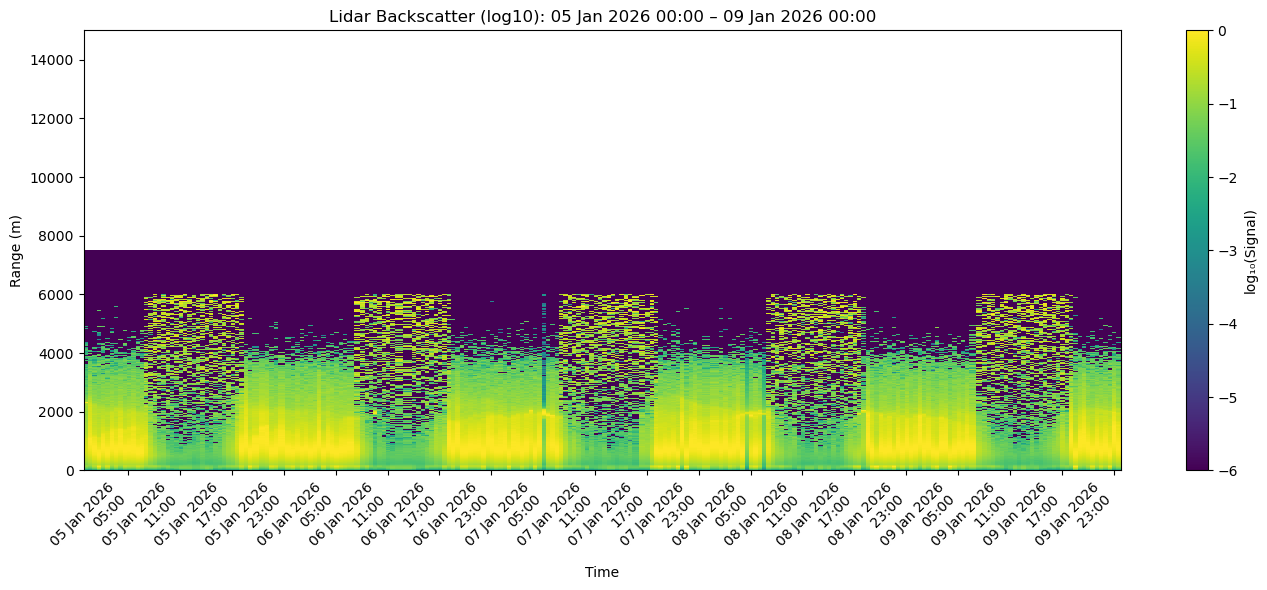

In [14]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="MyLidarFigures"
)

Saved figure → MyLidarFigures/lidar_Linear_20260105_0000_20260109_0000.png


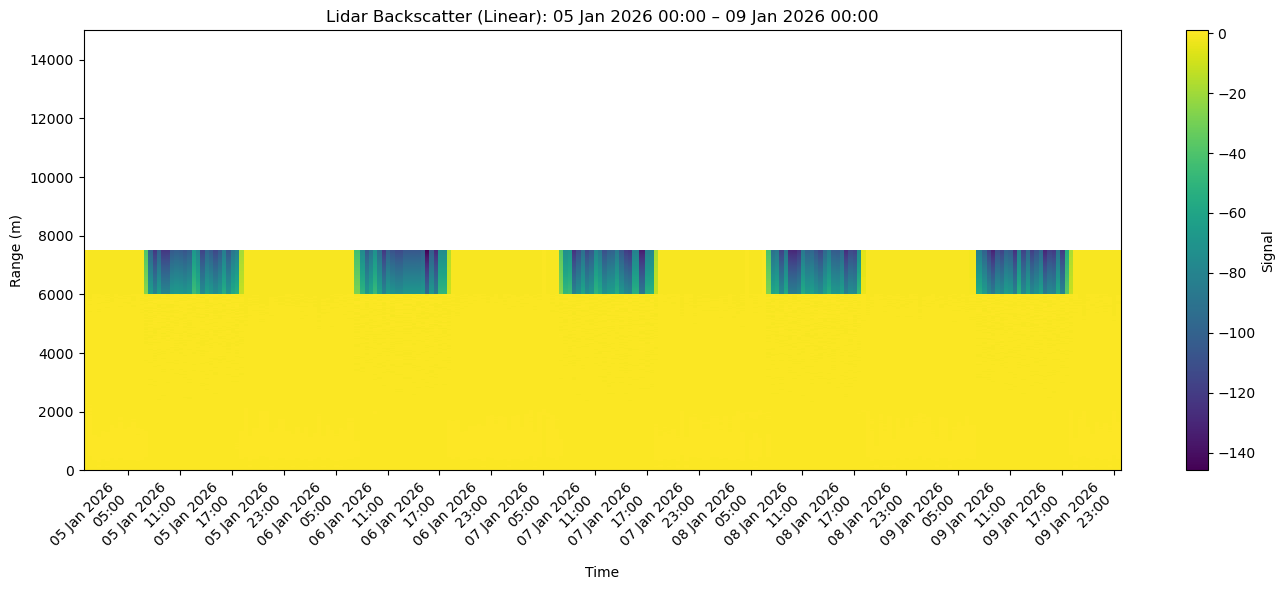

In [15]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    save=True,
    save_dir="MyLidarFigures"
)

In [44]:
def plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="figures",
    ylim=None,
    xlim=None,
    clim=None,
    cmap="jet",
    invert_y=False,
):
    """
    Z : 2D DataFrame (range_m × datetime)

    scale : "linear" or "log"
    ylim  : tuple (ymin, ymax) or None
    xlim  : tuple (xmin, xmax) datetime or None
    clim  : tuple (vmin, vmax) or None
    cmap  : matplotlib colormap
    invert_y : True/False
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from datetime import timedelta

    # --- Scale handling ---
    if scale == "log":
        Z_plot = np.log10(Z.clip(lower=1e-6))
        color_label = "log₁₀(Signal)"
        title_scale = "log10"
    elif scale == "linear":
        Z_plot = Z.copy()
        color_label = "Signal"
        title_scale = "Linear"
    else:
        raise ValueError("scale must be 'linear' or 'log'")

    fig, ax = plt.subplots(figsize=(8, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns,
        Z_plot.index,
        Z_plot.values,
        shading="auto",
        cmap=cmap
    )

    # --- Time formatting ---
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d %b %Y\n%H:%M')
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")

    # --- Optional axis limits ---
    if ylim is not None:
        ax.set_ylim(ylim)

    if xlim is not None:
        ax.set_xlim(xlim)

    if invert_y:
        ax.invert_yaxis()

    # --- Optional color limits ---
    if clim is not None:
        pcm.set_clim(*clim)
        
    end_date_fixed = end_date.replace(hour=23, minute=59)
    
    ax.set_title(
        f"Lidar Backscatter ({title_scale}): "
        f"{start_date:%d %b %Y %H:%M} – {end_date_fixed:%d %b %Y %H:%M}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)

    plt.tight_layout()

    # --- Save section ---
    if save:
        os.makedirs(save_dir, exist_ok=True)

        filename = (
            f"lidar_{title_scale}_Pro"
            f"{start_date:%Y%m%d_%H%M}_"
            f"{(end_date + timedelta(days=1)):%Y%m%d_%H%M}.png"
        )

        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Saved figure → {save_path}")

    plt.show()


Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


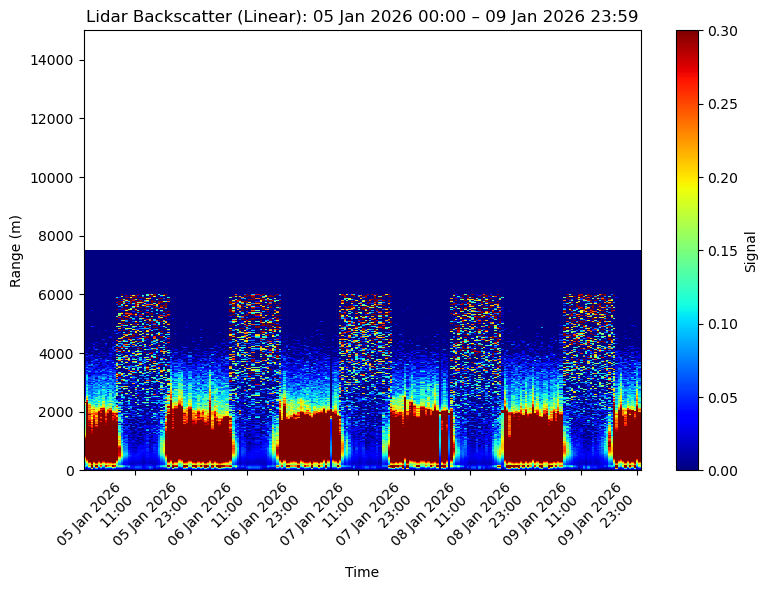

In [46]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.3)
)

Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


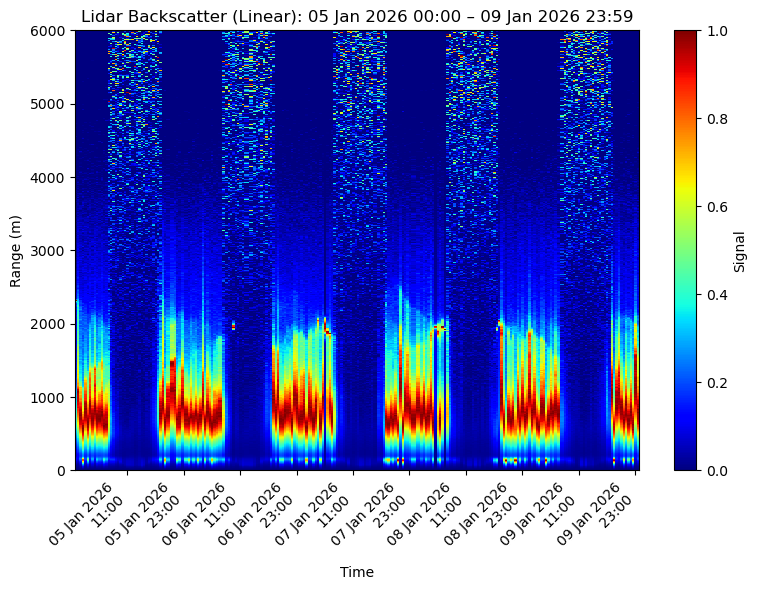

In [59]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 6000),
    clim=(0, 1)
)

Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


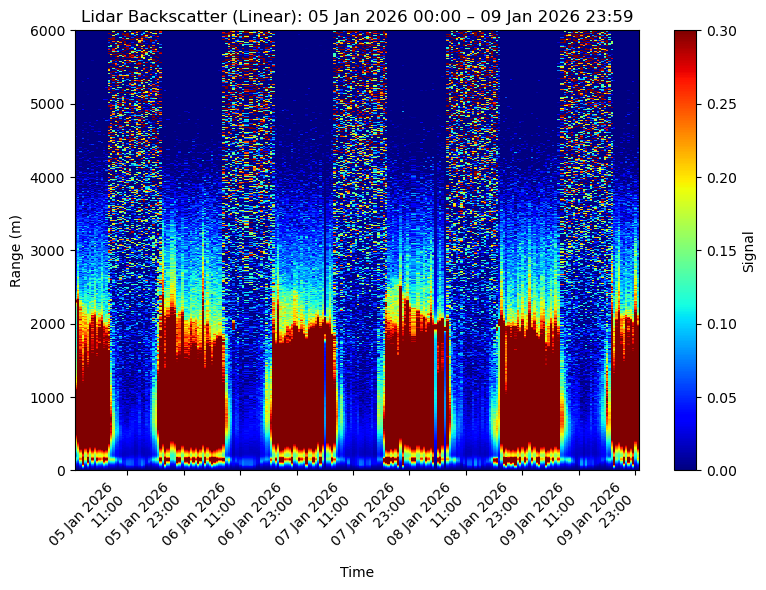

In [57]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 6000),
    clim=(0, 0.3)
)

Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


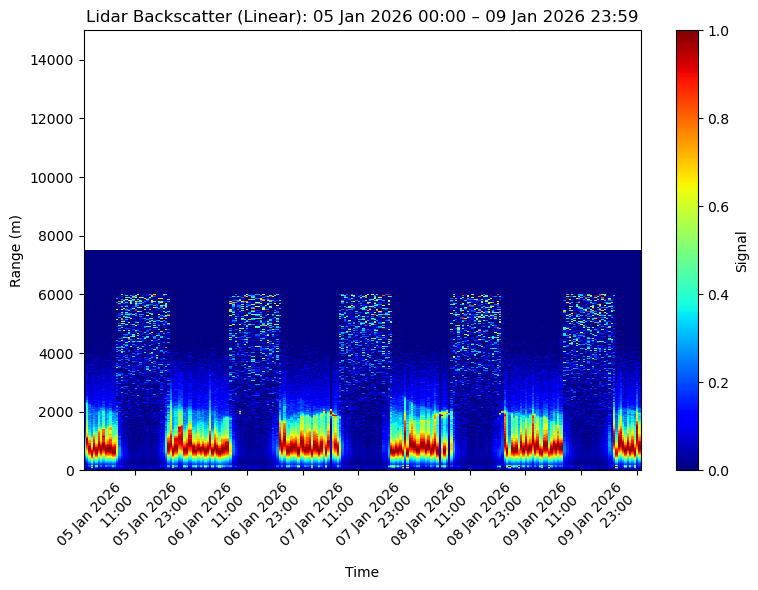

In [47]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 1)
)

Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


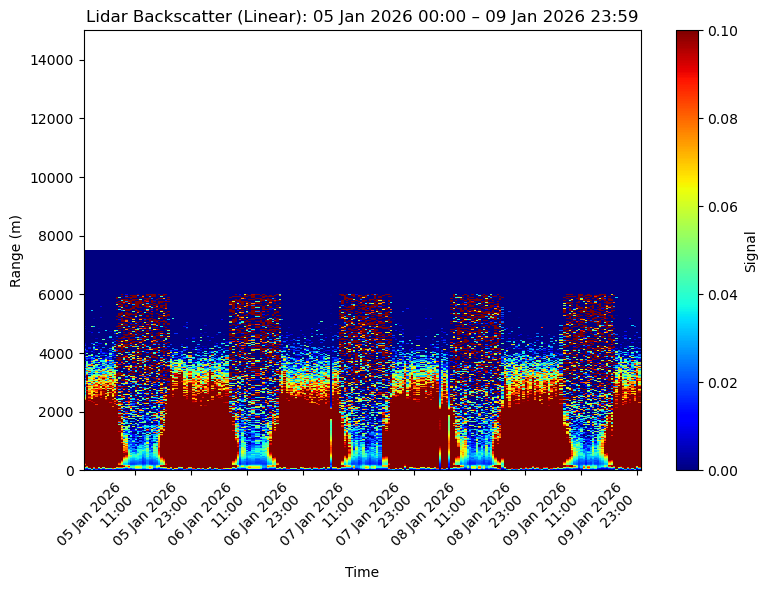

In [55]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.1)
)

Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


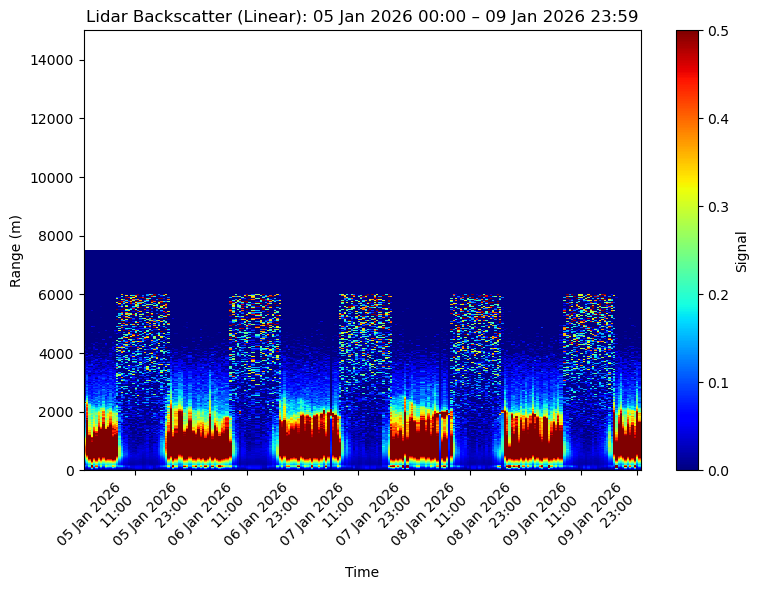

In [49]:
plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.5)
)

Saved figure → figures/lidar_Linear_Pro20260105_0000_20260110_0000.png


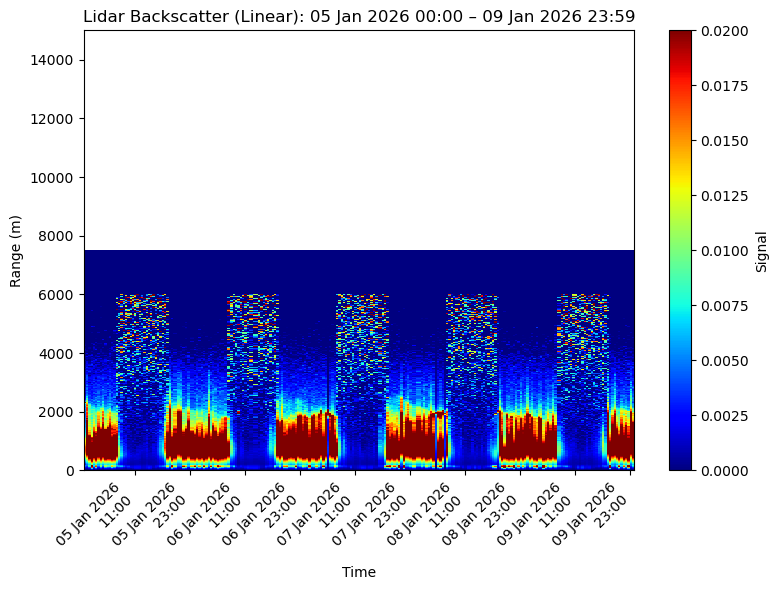

In [50]:
plot_lidar_curtain(
    Z/25,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.02)
)